<a href="https://colab.research.google.com/github/Samuelameningayeh/thesis/blob/main/synthetic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# import cmdstanpy
# cmdstanpy.install_cmdstan()


In [3]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import seaborn as sns
from cmdstanpy import CmdStanModel, cmdstan_path
import arviz as az
from pathlib import Path

from scipy.integrate import odeint

import logging
cmdstanpy_logger = logging.getLogger("cmdstanpy")
cmdstanpy_logger.disabled = True

# Define the SEIR model

$$ 
\begin{aligned}
\frac{dS_p}{dt} &= -\beta_p S_p \frac{I_p}{N_p}\\

\frac{dE_p}{dt} &= \beta_p S_p \frac{I_p}{N_p} - \sigma_p E_p \\

\frac{dI_p}{dt} &= \sigma_p E_p - \gamma_p I_p\\

\frac{dR_p}{dt} &= \gamma_p I_p
\end{aligned}
$$

Where:
- $ S_p, E_p, I_p, R_p $: Susceptible, Exposed, Infectious, and Recovered individuals in patch $ p $.
- $ N_p $: Total population for patch $ p $.
- $ \beta_p $: Transmission rate in patch $ p $.
- $ \sigma_p $: Rate of progression from Exposed to Infectious (inverse of the latent period).
- $ \gamma_p $: Recovery rate (inverse of the infectious period).

In [4]:
# ---- SEIR ODE system --------------------------------------------------------
def seir(state, t, beta, sigma, gamma, N):
    n=len(N)
    S = state[:n]
    E = state[n:2*n]
    I = state[2*n:3*n]
    R = state[3*n:4*n]
    C = state[4*n:]

    dS = np.zeros(n)
    dE = np.zeros(n)
    dI = np.zeros(n)
    dR = np.zeros(n)
    dC = np.zeros(n)
    
    for i in range(n):
        dS[i] = -beta[i] * S[i] * I[i] / N[i]
        dE[i] =  beta[i] * S[i] * I[i] / N[i] - sigma[i] * E[i]
        dI[i] =  sigma[i] * E[i] - gamma[i] * I[i]
        dR[i] =  gamma[i] * I[i]
        dC[i] = sigma[i] * E[i]
    
    return np.concatenate([dS.flatten(), dE.flatten(), dI.flatten(), dR.flatten(), dC.flatten()])


# Define Parameters

In [5]:
n_regions = 3 
T = 96 #679/7
# Time vector
t = np.linspace(0, T, T)

N = [11.5e6, 4.5e6, 6.8e6]  # Guinea, Liberia, Sierra Leone
# N=[1000000, 960000, 745000]
# N = np.array([110000, 440000, 680000])

## Get the Parameters
beta = np.array([0.3, 0.4, 0.35])*7  # Transmission rate per week (R0 = beta/gamma)
sigma = np.array([1/8.5, 1/8.5, 1/8.5])*7 #incubation rate per week
gamma = np.array([1/13, 1/14, 1/13])*7     # 1/infectious period per week (Ebola: ~7 days)

phi = 10           # Negative binomial dispersion parameter
reporting_rate = 1 #0.8  # Proportion of cases reported

# Initial conditions
E0 = np.array([10, 10, 10])
I0 = np.array([10, 10, 10])
R0 = np.array([0,0,0])
C0 = np.array([0,0,0])
S0 = np.array([N[0]-10, N[1]-10, N[2]-10])

# initial_state = [guinea, lib, sir]
y0 = np.concatenate([S0.flatten(), E0.flatten(), I0.flatten(), R0.flatten(), C0.flatten()])


# Solve the ODEs

In [6]:
# Simulate SEIR for each region
sol = odeint(seir, y0, t, args=(beta, sigma, gamma, N))

## Get the New Infections and Deaths

In [7]:
n = 3
# Extract and aggregate results
# S = sol[:, :n]
# E = sol[:, n:2*n]
# I = sol[:, 2*n:3*n]
# R = sol[:, 3*n:4*n]
# D = sol[:, 4*n:]

## Total per patch (sum over resident patches i)
S_total = sol[:, :n]
E_total = sol[:, n:2*n]
I_total = sol[:, 2*n:3*n]
R_total = sol[:, 3*n:4*n]
C_total = sol[:, 4*n:]


## get the new infected individuals at each time
Infections = np.zeros([T, n])

for j in range(3):
    ## get new infections
    for i in (range(len(C_total))):

        if (i+1 == len(C_total)):
            new_infections = [0.0,0.0,0.0]
            Infections[i, j] = new_infections[j]
        else:
            new_infections = C_total[i+1] - C_total[i]
            Infections[i+1, j] = new_infections[j]

## Show New infections

In [8]:
Infections[:100]

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.36662118e+01, 1.69200114e+01, 1.51935682e+01],
       [2.76637330e+01, 4.33549632e+01, 3.44370726e+01],
       [5.31141385e+01, 1.04247607e+02, 7.34790501e+01],
       [1.01618253e+02, 2.49950962e+02, 1.56270982e+02],
       [1.94366588e+02, 5.99147418e+02, 3.32273469e+02],
       [3.71751493e+02, 1.43575269e+03, 7.06429533e+02],
       [7.10986509e+02, 3.43805697e+03, 1.50161050e+03],
       [1.35965258e+03, 8.21862062e+03, 3.19055454e+03],
       [2.59964593e+03, 1.95659366e+04, 6.77319618e+03],
       [4.96874680e+03, 4.61286806e+04, 1.43519875e+04],
       [9.49043353e+03, 1.06305070e+05, 3.02913453e+04],
       [1.81035997e+04, 2.32702377e+05, 6.34049546e+04],
       [3.44489472e+04, 4.57220717e+05, 1.30447846e+05],
       [6.52466612e+04, 7.37392366e+05, 2.59142171e+05],
       [1.22492714e+05, 8.91144727e+05, 4.81017595e+05],
       [2.26210466e+05, 7.85385341e+05, 7.91358341e+05],
       [4.05368506e+05, 5.36368

## Add Noise

In [9]:
def Add_noise(data, reporting_rate, phi, seed=None):
    """
    Adds negative binomial noise to data with a fixed seed for reproducibility.

    Args:
        data: array-like, true (latent) cases, shape [patches, time]
        reporting_rate: float, observed/reporting probability
        phi: int or float, dispersion parameter for NegBin (higher = less variance)
        seed: int or None, seed for np.random

    Returns:
        observed_cases: np.ndarray of noisy observed cases
    """
    if seed is not None:
        np.random.seed(seed)  # Set random seed for reproducibility

    data = np.array(data)
    observed_cases = []
    for i in range(data.shape[0]):
        case = []
        for t in range(data.shape[1]):
            mean_cases = reporting_rate * data[i, t]
            p = phi / (phi + mean_cases)
            # Avoid edge case for p > 1 (when mean_cases is 0)
            p = np.clip(p, 0, 1)
            case.append(np.random.negative_binomial(phi, p))
        observed_cases.append(case)
    return np.array(observed_cases)



In [10]:
observed_cases = Add_noise(Infections, reporting_rate= reporting_rate, phi=phi, seed=0)
c = pd.DataFrame(observed_cases, columns = ['Guinea', 'Liberia', 'Sierra Leone'])


## Create a dataframe

In [11]:
# Create dataset
data = {
    'time': pd.date_range(start='2013-12-28', periods=T, freq='D'),
    'Day': t.astype(int),
    'S_Guinea': S_total[:, 0],
    'E_Guinea': E_total[:, 0],
    'I_Guinea': I_total[:, 0],
    'R_Guinea': R_total[:, 0],
    'C_Guinea': C_total[:, 0],
    'Guinea_New_case': Infections[:, 0],
    'Guinea_Noise' : c['Guinea'],

    'S_Liberia': S_total[:, 1],
    'E_Liberia': E_total[:, 1],
    'I_Liberia': I_total[:, 1],
    'R_Liberia': R_total[:, 1],
    'C_Liberia': C_total[:, 1],
    'Liberia_New_case': Infections[:, 1],
    'Liberia_Noise' : c['Liberia'],

    'S_SierraLeone': S_total[:, 2],
    'E_SierraLeone': E_total[:, 2],
    'I_SierraLeone': I_total[:, 2],
    'R_SierraLeone': R_total[:, 2],
    'C_SierraLeone': C_total[:, 2],
    'SierraLeone_New_case': Infections[:, 2],
    'SierraLeone_Noise' : c['Sierra Leone'],
}

raw = pd.DataFrame(data)
raw.to_csv('Data/synthetic_ebola_dataset_with_death.csv', index=False)
raw.head()

,time,Day,S_Guinea,E_Guinea,I_Guinea,R_Guinea,C_Guinea,Guinea_New_case,Guinea_Noise,S_Liberia,...,C_Liberia,Liberia_New_case,Liberia_Noise,S_SierraLeone,E_SierraLeone,I_SierraLeone,R_SierraLeone,C_SierraLeone,SierraLeone_New_case,SierraLeone_Noise
0,2013-12-28,0,1.149999e+07,10.000000,10.000000,0.000000,0.000000,0.000000,0,4.499990e+06,...,0.000000,0.000000,0,6.799990e+06,10.000000,10.000000,0.000000,0.000000,0.000000,0
1,2013-12-29,1,1.149996e+07,23.399405,16.726296,6.939916,13.666212,13.666212,8,4.499951e+06,...,16.920011,16.920011,18,6.799957e+06,27.451184,18.018870,7.174699,15.193568,15.193568,19
2,2013-12-30,2,1.149991e+07,45.320571,31.675884,19.654061,41.329945,27.663733,23,4.499861e+06,...,60.274975,43.354963,53,6.799891e+06,59.106627,37.929953,21.700688,49.630641,34.437073,66
3,2013-12-31,3,1.149982e+07,86.759757,60.545298,43.898786,94.444083,53.114138,79,4.499648e+06,...,164.522582,104.247607,97,6.799751e+06,125.769365,80.607800,52.501891,123.109691,73.479050,58
4,2014-01-01,4,1.149964e+07,165.954887,115.800049,90.262286,196.062336,101.618253,97,4.499135e+06,...,414.473544,249.950962,227,6.799453e+06,267.434274,171.394535,117.986138,279.380673,156.270982,127


# Plot the results

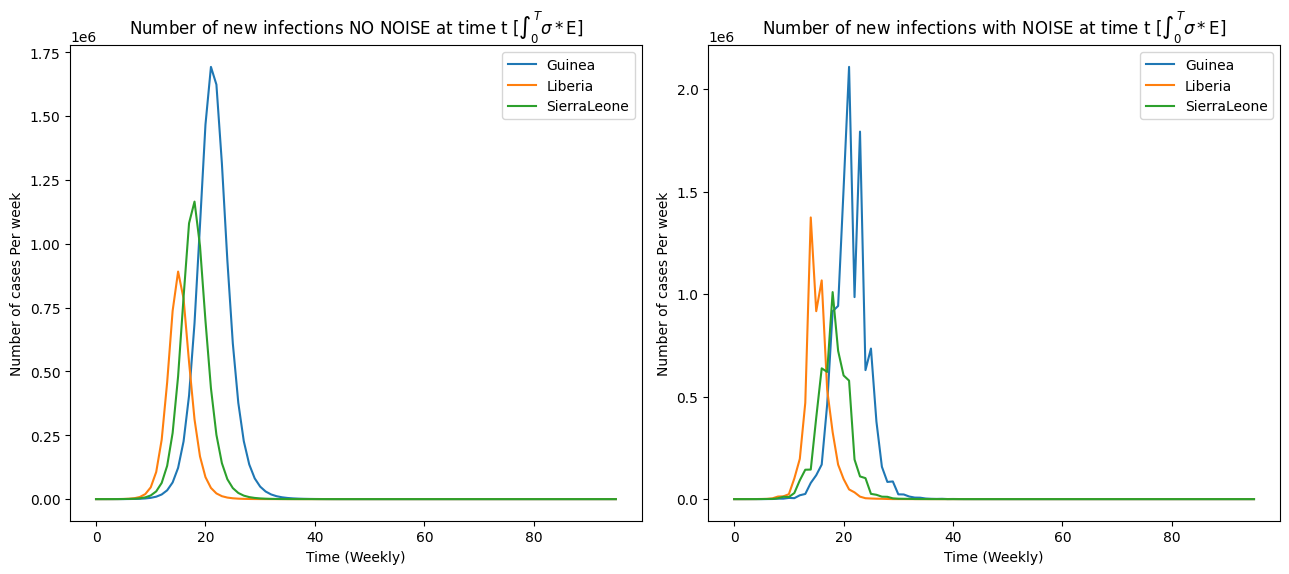

In [12]:
fig, ax = plt.subplots(1,2, figsize = (13, 6))
countries = ['Guinea', 'Liberia', 'SierraLeone']
for i in range(3):
    ax[0].plot(raw[f'{countries[i]}_New_case'])
    ax[0].legend(countries)
    ax[0].set_title('Number of new infections NO NOISE at time t $[\int_0^T \sigma*$E]')
    ax[0].set_xlabel('Time (Weekly)')
    ax[0].set_ylabel('Number of cases Per week')

    ax[1].plot(raw[f'{countries[i]}_Noise'])
    ax[1].legend(countries)
    ax[1].set_title('Number of new infections with NOISE at time t $[\int_0^T \sigma*$E]')
    ax[1].set_xlabel('Time (Weekly)')
    ax[1].set_ylabel('Number of cases Per week')

    # ax[2].plot(raw[f'C_{countries[i]}'])
    # ax[2].legend(countries)
    # ax[2].set_title('Number of Infections at time t [$ \sigma$ * E]')
    # ax[2].set_xlabel('Time (Weekly)')
    # ax[2].set_ylabel('Number of cases per week')

plt.tight_layout()
plt.savefig('images/generated_no_coupling.pdf')
plt.show()

In [17]:
# Plot for each country
countries = ['Guinea', 'Liberia', 'SierraLeone']
def plot_SEIR(df, country_name, Death = False, save=False, yscale = False):
    # Extract data for the current country
    S = df[f'S_{country_name}']
    E = df[f'E_{country_name}']
    I = df[f'I_{country_name}']
    R = df[f'R_{country_name}']

    # Create plot
    plt.figure(figsize=(13, 6))
    plt.plot(df['Day'], S, label='Susceptible', color='blue')
    plt.plot(df['Day'], E, label='Exposed', color='orange')
    plt.plot(df['Day'], I, label='Infective', color='red')
    plt.plot(df['Day'], R, label='Removed', color='green')
    if Death:
        D = df[f'D_{country_name}']
        plt.plot(df['Day'], D, label='Death', color='black')

    # Customize the plot
    plt.xlabel('Day')
    plt.ylabel('Number of Individuals')
    plt.title(f'SEIRD Dynamics for {country_name}')
    plt.legend()
    plt.grid(True)
    if yscale:
        plt.yscale('symlog')  # Use symlog scale to handle large ranges
    if save:
        plt.savefig(f'seird_{country_name.lower()}.png')
    plt.show()

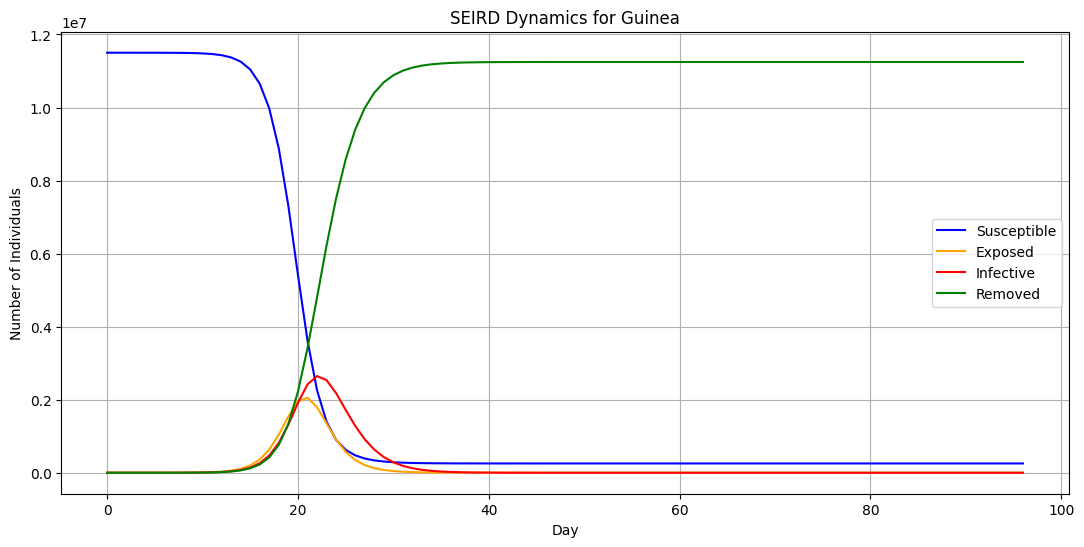

In [18]:
plot_SEIR(raw, 'Guinea')

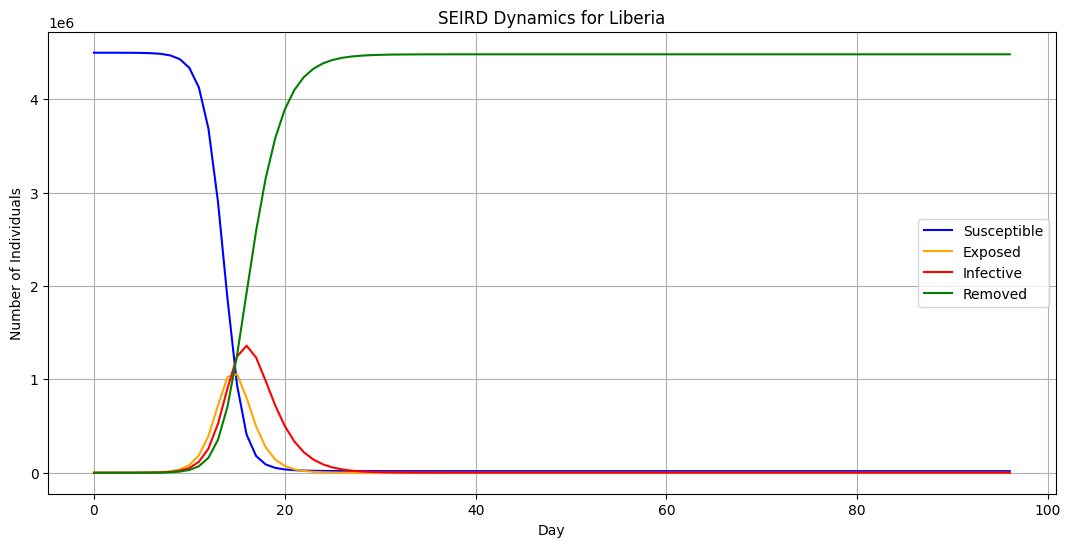

In [19]:
plot_SEIR(raw, 'Liberia')

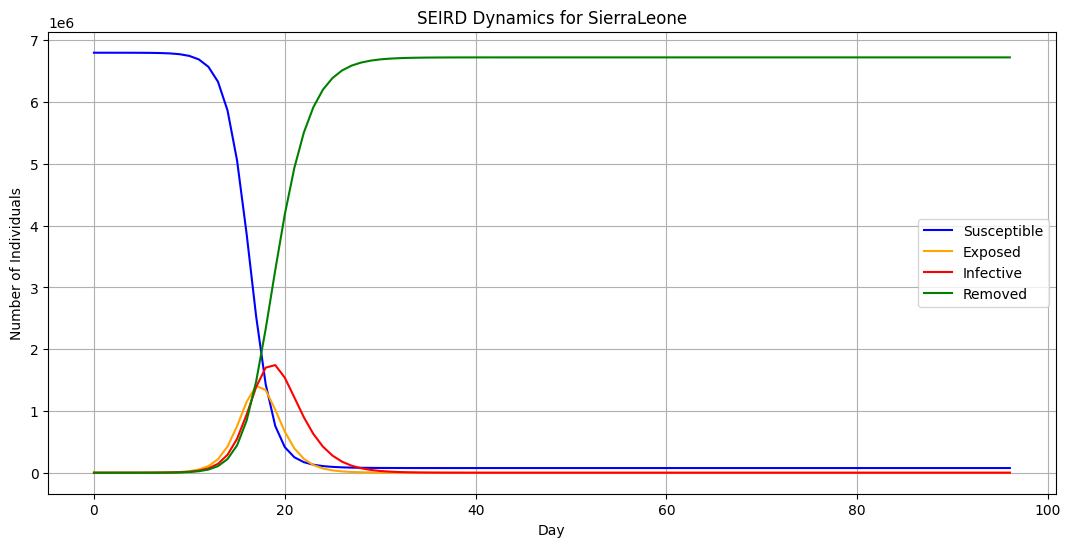

In [20]:
plot_SEIR(raw, 'SierraLeone')

# Create a function to plot Posterior for Parameters

# Fit the Model to daily cases


In [22]:
# Aggregate cases by country and week
countries = ['Guinea', 'Liberia', 'Sierra Leone']
# weekly_cases = df.groupby(['country', pd.Grouper(key='time', freq='W')]).sum().unstack(fill_value=0).T
weekly_cases1 = raw['Guinea_Noise']
weekly_cases2 = raw['Liberia_Noise']
weekly_cases3 = raw['SierraLeone_Noise']

cases1 = weekly_cases1.values  # Shape: (T, 3)
cases2 = weekly_cases2.values  # Shape: (T, 3)
cases3 = weekly_cases3.values  # Shape: (T, 3)

N = np.array([11.5e6, 4.5e6, 6.8e6]) 
# N = np.array([110000, 440000, 680000]) 
# N=np.array([2e6, 1.5e6, 1e6])
# Set the population size
# N = n[0] #763

beta = np.array([0.3, 0.4, 0.35])*7  # Transmission rate (R0 = beta/gamma)
sigma = np.array([1/8.5, 1/8.5, 1/8.5])*7
gamma = np.array([1/13, 1/14, 1/13])*7

phi = 10           # Negative binomial dispersion parameter
reporting_rate = 1 

# Define initial conditions
i0 = [10, 10, 10]
e0 = [10, 1, 1]
s0 = N - i0
r0 = [0, 0, 0]
c0 = [0, 0, 0]
y1 = [s0[0], e0[0], i0[0], r0[0], c0[0]]
y2 = [s0[1], e0[1], i0[1], r0[1], c0[1]]
y3 = [s0[2], e0[2], i0[2], r0[2], c0[2]]


In [27]:

# Make the data struture
seir_data1 = {
    "n_days": len(cases1),
    "y0": y1,
    "t0": 0,
    "t": np.arange(1, len(cases1)+1),
    "N": int(N[0]),
    "cases": cases1,
    'beta_value': beta[0],
    'sigma_value': sigma[0],
    'gamma_value': gamma[0],
    "reporting_rate": reporting_rate
}

seir_data2 = {
    "n_days": len(cases2),
    "y0": y2,
    "t0": 0,
    "t": np.arange(1, len(cases2)+1),
    "N": int(N[1]),
    "cases": cases2,
    'beta_value': beta[1],
    'sigma_value': sigma[1],
    'gamma_value': gamma[1],
    "reporting_rate": reporting_rate
}
seir_data3 = {
    "n_days": len(cases3),
    "y0": y3,
    "t0": 0,
    "t": np.arange(1, len(cases3)+1),
    "N": int(N[2]),
    "cases": cases3,
    'beta_value': beta[2],
    'sigma_value': sigma[2],
    'gamma_value': gamma[2],
    "reporting_rate": reporting_rate
}

seir_incidence_model1 = CmdStanModel(stan_file = 'stan files/simple_seir.stan')
seir_incidence_model2 = CmdStanModel(stan_file = 'stan files/simple_seir.stan')
seir_incidence_model3 = CmdStanModel(stan_file = 'stan files/simple_seir.stan')

In [ ]:
fit1 = seir_incidence_model1.sample(data = seir_data1,
                                    #    iter_warmup= 500,
                                    iter_sampling = 1000,
                                    parallel_chains=True,
                                    chains = 4,
                                    seed = 0)

chain 1 |          | 00:00 Status


chain 1 |██████████| 04:34 Iteration: 1900 / 2000 [ 95%]  (Sampling)













In [ ]:
fit2 = seir_incidence_model2.sample(data = seir_data2,
                                   iter_sampling = 1000,
                                   parallel_chains=True,
                                   chains = 4,
                                   seed = 2)

chain 1 |          | 00:00 Status


chain 1 |██████████| 21:43 Iteration: 1900 / 2000 [ 95%]  (Sampling)

































































chain 1 |██████████| 52:19 Sampling completed                       
chain 2 |██████████| 52:19 Sampling completed                       
chain 3 |██████████| 52:19 Sampling completed                       
chain 4 |██████████| 52:19 Sampling completed                       

In [ ]:
fit3 = seir_incidence_model3.sample(data = seir_data3,
                                   iter_sampling = 1000,
                                   parallel_chains=True,
                                   chains = 4,
                                   seed = 0)

chain 1 |          | 00:00 Status


chain 1 |██████████| 44:43 Iteration: 1900 / 2000 [ 95%]  (Sampling)

































































chain 1 |██████████| 3:49:53 Sampling completed                     
chain 2 |██████████| 3:49:53 Sampling completed                       
chain 3 |██████████| 3:49:53 Sampling completed                       
chain 4 |██████████| 3:49:53 Sampling completed                       

In [28]:
fit1_summary = fit1.summary()
fit1_summary.filter(items=("sigma", "beta", "gamma", "alpha", "recovery_time", "incubation_period", "R0", "phi", "phi_inv"), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
sigma,2.279430,1.271290,1.802260,1.384830,0.717078,1.788190,5.27091,5.02613,2000.0,2.80593
beta,1.139720,0.622021,0.888964,1.121240,0.159694,0.915952,2.26166,5.22187,2000.0,2.11841
gamma,0.579657,0.223487,0.326449,0.450917,0.205000,0.509157,1.07626,4.74911,2000.0,2.62691
alpha,1.923740,1.258720,1.784020,1.634010,0.285729,1.501590,4.76946,5.06631,2000.0,2.87746
recovery_time,2.476140,1.037530,1.507000,1.534210,0.929141,1.964030,4.87805,4.75420,2000.0,2.61895
incubation_period,0.754046,0.308955,0.449600,0.576443,0.189720,0.578526,1.39455,5.01845,2000.0,2.28985
R0,1.125620,0.752222,1.071840,1.244020,0.050208,0.889284,2.43971,5.20308,2000.0,2.24833
phi,3.403620,2.339670,3.404800,2.818740,0.000001,1.901210,8.38659,4.99277,2000.0,2.31116
phi_inv,209216.000000,255882.000000,362416.000000,3.044660,0.119238,2.185720,837001.00000,4.99665,2000.0,2.36071


In [29]:
fit2_summary = fit2.summary()
fit2_summary.filter(items=("sigma", "beta", "gamma", "alpha", "recovery_time", "incubation_period", "R0", "phi", "phi_inv"), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
sigma,0.907753,0.002591,0.113696,0.103705,0.758333,0.890323,1.118220,2289.28,1737.41,1.00210
beta,2.580680,0.004999,0.214542,0.214910,2.258960,2.569740,2.950730,1860.58,2405.57,1.00347
gamma,0.464395,0.002233,0.104534,0.100833,0.308893,0.453767,0.654481,2218.51,2416.44,1.00093
alpha,0.402841,0.002089,0.097961,0.098717,0.256715,0.395955,0.573328,2210.52,2167.85,1.00259
recovery_time,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
incubation_period,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
R0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
phi,10.925400,0.051619,2.809360,2.729930,6.837130,10.675600,15.907600,2957.89,1833.78,1.00176
phi_inv,0.097881,0.000513,0.026467,0.023871,0.062863,0.093671,0.146260,2957.87,1833.78,1.00176


In [30]:
fit3_summary = fit3.summary()
fit3_summary.filter(items=("sigma", "beta", "gamma", "alpha", "recovery_time", "incubation_period", "R0", "phi", "phi_inv"), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
sigma,3.603260,NaN,3.847020,1.467540,0.860426,2.012510,10.22000,NaN,NaN,NaN
beta,1.319890,NaN,1.043700,1.448190,0.161196,1.137980,2.63715,NaN,NaN,NaN
gamma,0.619099,NaN,0.332247,0.538185,0.208750,0.571751,1.10101,NaN,NaN,NaN
alpha,2.558160,NaN,2.743060,1.695320,0.305945,1.578000,7.14158,NaN,NaN,NaN
recovery_time,2.332020,NaN,1.500730,1.246420,0.908253,1.749010,4.79043,NaN,NaN,NaN
incubation_period,0.632890,NaN,0.384040,0.593362,0.097847,0.498065,1.16222,NaN,NaN,NaN
R0,1.176640,NaN,1.131140,1.291200,0.048829,0.919733,2.54171,NaN,NaN,NaN
phi,4.661610,3.32501,4.889140,3.018350,0.000004,2.035850,12.04770,NaN,NaN,NaN
phi_inv,87141.700000,NaN,105944.000000,65957.600000,0.083004,44487.900000,259461.00000,NaN,NaN,NaN


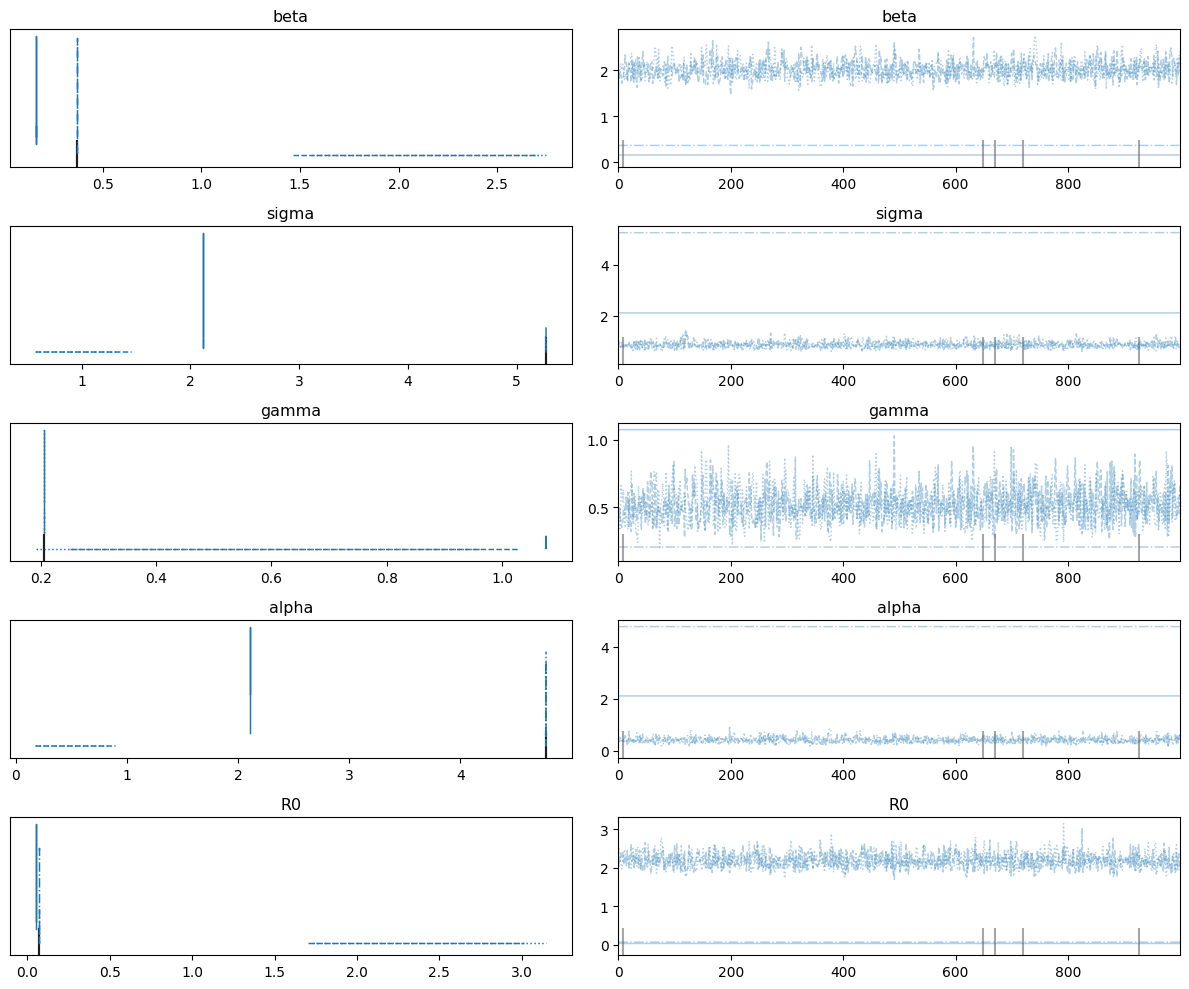

In [31]:
## trace plots
az.plot_trace(fit1, var_names=["beta", "sigma", "gamma", "alpha", "R0"])
plt.tight_layout()
plt.show()

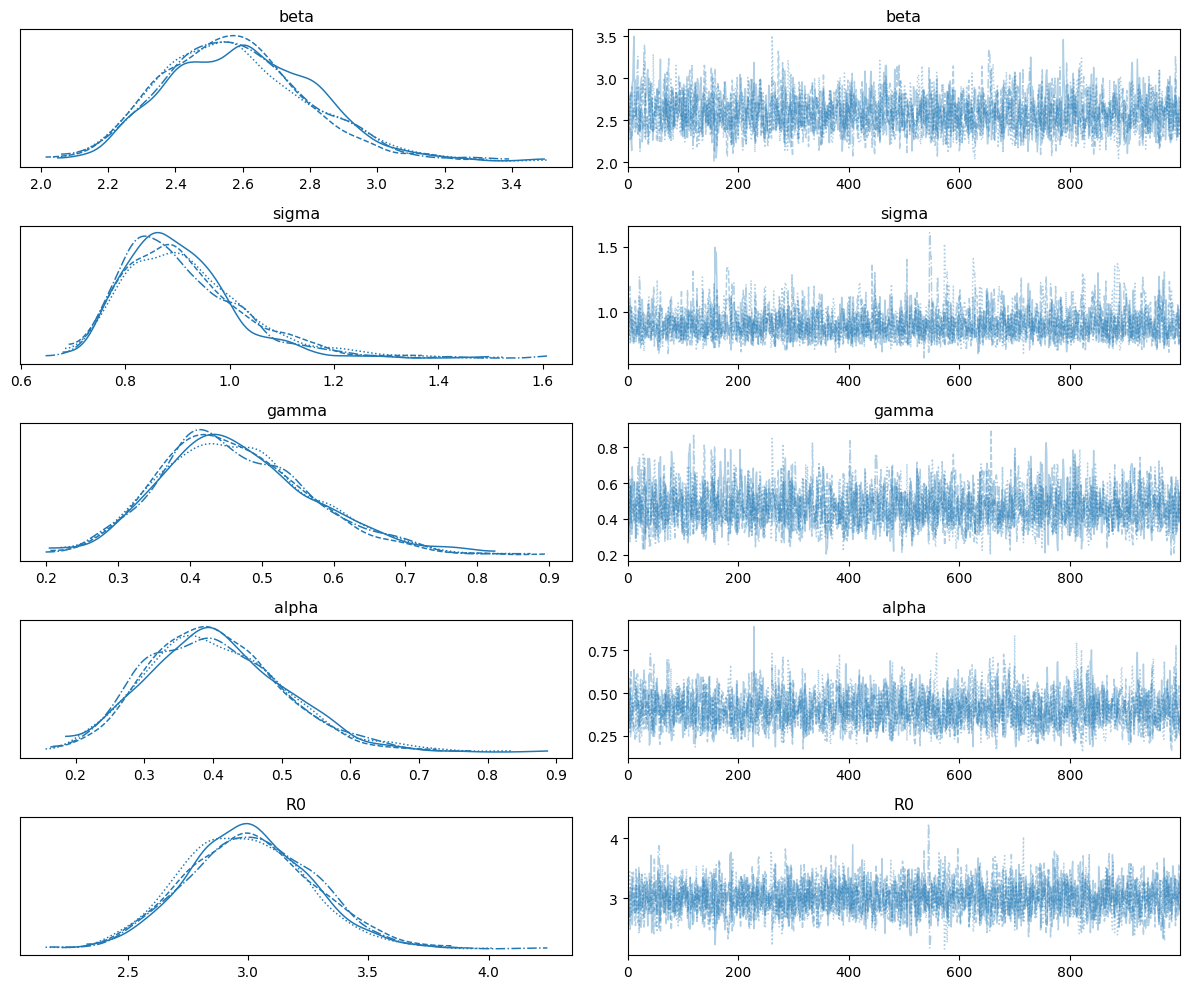

In [32]:
az.plot_trace(fit2, var_names=["beta", "sigma", "gamma", "alpha", "R0"])
plt.tight_layout()
plt.show()

/media/brasammy/5B6DAD9B6A1F7E40/Projects/cleaned-thesis/myenv/lib/python3.11/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/media/brasammy/5B6DAD9B6A1F7E40/Projects/cleaned-thesis/myenv/lib/python3.11/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/media/brasammy/5B6DAD9B6A1F7E40/Projects/cleaned-thesis/myenv/lib/python3.11/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/media/brasammy/5B6DAD9B6A1F7E40/Projects/cleaned-thesis/myenv/lib/python3.11/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to 

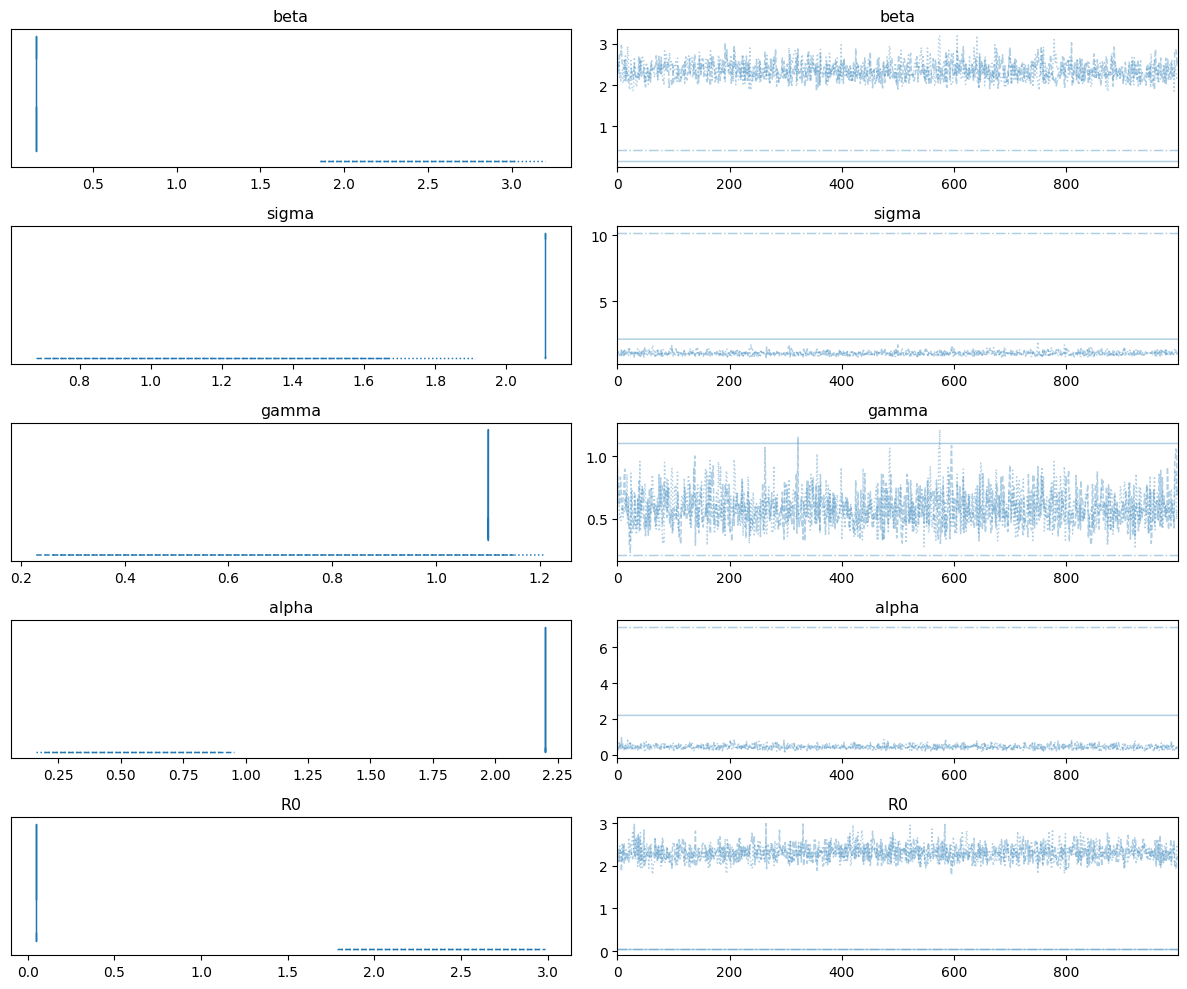

In [33]:
az.plot_trace(fit3, var_names=["beta", "sigma", "gamma", "alpha", "R0"])
plt.tight_layout()
plt.show()

In [34]:
# Extract posterior samples
post_guinea = fit1.draws_pd()
post_liberia = fit2.draws_pd()
post_sierra = fit3.draws_pd()

## save the posterior samples
post_guinea.to_csv('./Data/posterior_samples_guinea.csv', index=False)
post_liberia.to_csv('./Data/posterior_samples_liberia.csv', index=False)
post_sierra.to_csv('./Data/posterior_samples_sierra.csv', index=False)

# Posterior Predictive Checks

In [35]:
fit1_summary.filter(like="pred_incidence", axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
pred_incidence[1],9.22125,NaN,14.339700,10.3782,0.0,7.0,26.0,NaN,NaN,NaN
pred_incidence[2],10.29200,NaN,12.130700,4.4478,0.0,3.0,33.0,NaN,NaN,NaN
pred_incidence[3],15.89780,NaN,18.643500,2.9652,0.0,2.0,50.0,NaN,NaN,NaN
pred_incidence[4],23.94430,NaN,27.940600,3.7065,0.0,2.5,75.0,NaN,NaN,NaN
pred_incidence[5],36.78970,NaN,42.606700,5.9304,0.0,4.0,114.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
pred_incidence[92],0.00050,NaN,0.022358,0.0000,0.0,0.0,0.0,NaN,NaN,NaN
pred_incidence[93],0.00000,NaN,0.000000,0.0000,0.0,0.0,0.0,NaN,NaN,NaN
pred_incidence[94],0.00000,NaN,0.000000,0.0000,0.0,0.0,0.0,NaN,NaN,NaN
pred_incidence[95],0.00050,NaN,0.022358,0.0000,0.0,0.0,0.0,NaN,NaN,NaN


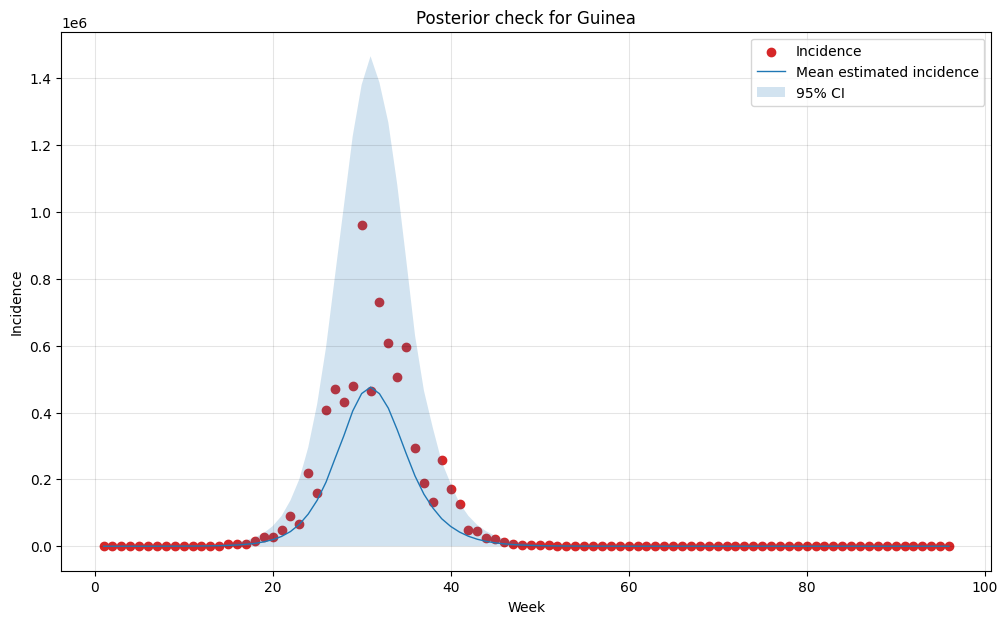

In [36]:
post_pred1 = pd.DataFrame(fit1_summary.filter(like="pred_incidence", axis=0))
post_pred1["t"] = range(1, T+1)
post_pred1["incidence"] = list(cases1)
post_pred1 = post_pred1.set_index("t")

plt.figure(figsize=(12, 7))
plt.grid(True, which='both', color = 'k', alpha = 0.1)
plt.title(f'Posterior check for Guinea')
plt.ylabel('Incidence')
plt.xlabel('Week')
plt.scatter(x = post_pred1.index, y = post_pred1.incidence, color = 'tab:red', label = "Incidence")
plt.plot(post_pred1.Mean, color = 'tab:blue', linewidth= 1, label = "Mean estimated incidence")
plt.fill_between(x = post_pred1.index, y1 = post_pred1['5%'], y2 = post_pred1['95%'], alpha=0.2, label="95% CI")
# plt.facecolor('white')
plt.legend(loc = "upper right")

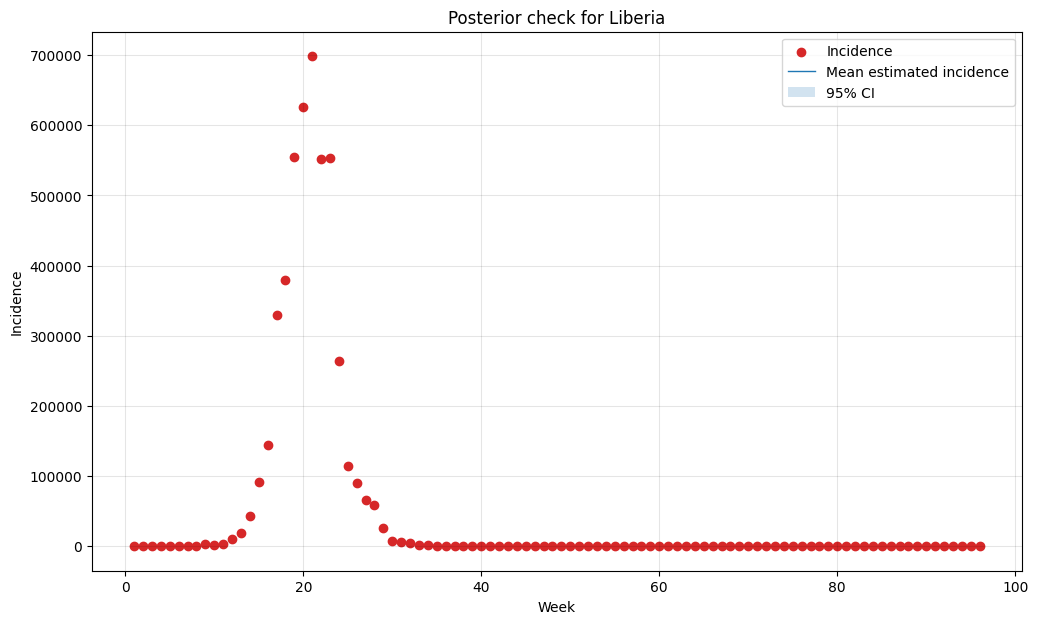

In [37]:
post_pred2 = pd.DataFrame(fit2_summary.filter(like="pred_incidence", axis=0))
post_pred2["t"] = range(1, T+1)
post_pred2["incidence"] = list(cases2)
post_pred2 = post_pred2.set_index("t")

plt.figure(figsize=(12, 7))
plt.grid(True, which='both', color = 'k', alpha = 0.1)
plt.title(f'Posterior check for Liberia')
plt.ylabel('Incidence')
plt.xlabel('Week')
plt.scatter(x = post_pred2.index, y = post_pred2.incidence, color = 'tab:red', label = "Incidence")
plt.plot(post_pred2.Mean, color = 'tab:blue', linewidth= 1, label = "Mean estimated incidence")
plt.fill_between(x = post_pred2.index, y1 = post_pred2['5%'], y2 = post_pred2['95%'], alpha=0.2, label="95% CI")
# plt.facecolor('white')
plt.legend(loc = "upper right")

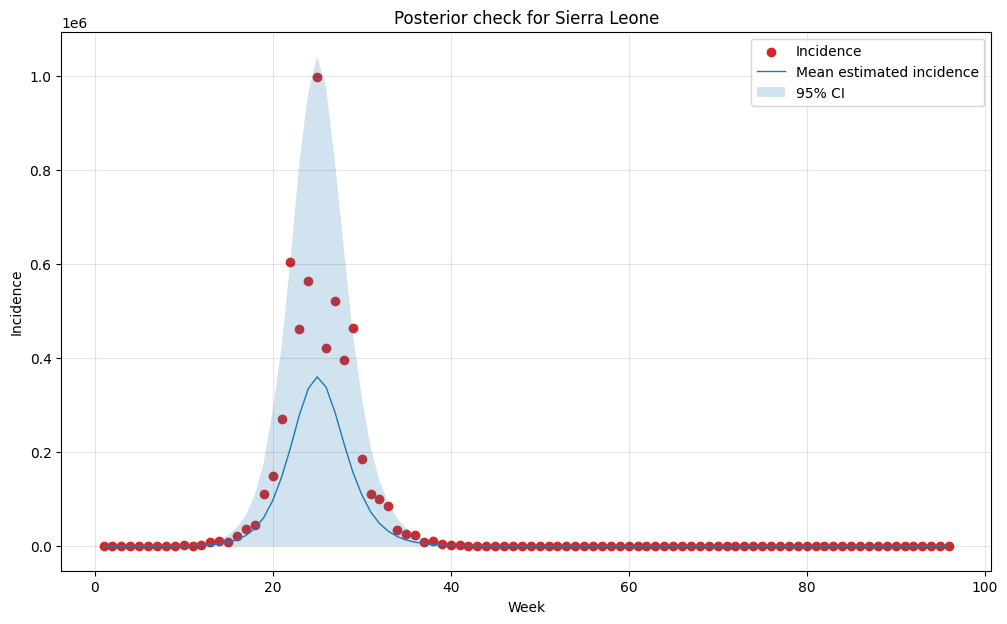

In [38]:
post_pred3 = pd.DataFrame(fit3_summary.filter(like="pred_incidence", axis=0))
post_pred3["t"] = range(1, T+1)
post_pred3["incidence"] = list(cases3)
post_pred3 = post_pred3.set_index("t")

plt.figure(figsize=(12, 7))
plt.grid(True, which='both', color = 'k', alpha = 0.1)
plt.title(f'Posterior check for Sierra Leone')
plt.ylabel('Incidence')
plt.xlabel('Week')
plt.scatter(x = post_pred3.index, y = post_pred3.incidence, color = 'tab:red', label = "Incidence")
plt.plot(post_pred3.Mean, color = 'tab:blue', linewidth= 1, label = "Mean estimated incidence")
plt.fill_between(x = post_pred3.index, y1 = post_pred3['5%'], y2 = post_pred3['95%'], alpha=0.2, label="95% CI")
# plt.facecolor('white')
plt.legend(loc = "upper right")

In [39]:
# Assuming `fit` is your CmdStanMCMC object from fitting the model
parameters1 = ["beta", "sigma", "recovery_time", "gamma", "incubation_period", "R0","phi"]

beta = np.array([0.3, 0.4, 0.35])*7  # Transmission rate (R0 = beta/gamma)
sigma = np.array([1/8.5, 1/8.5, 1/8.5])*7
gamma = np.array([1/13, 1/14, 1/13])*7
alpha = np.array([0.06, 0.05, 0.07])*7

phi = 10           # Negative binomial dispersion parameter
reporting_rate = 1 #0.8  # Proportion of cases reported
r = beta/(gamma+alpha)
rec = 1.0/gamma
incu = 1.0 / sigma

t1 = {'beta':beta[0],'sigma': sigma[0], 'gamma': gamma[0], 'phi': phi ,
    'reporting_rate':reporting_rate, 'R0': r[0], 'recovery_time':rec[0],
    'incubation_period': incu[0]}

t2 = {'beta':beta[1],'sigma': sigma[1], 'gamma': gamma[1], 'phi': phi ,
    'reporting_rate':reporting_rate, 'R0': r[1], 'recovery_time':rec[1],
    'incubation_period': incu[1]}

t3 = {'beta':beta[2],'sigma': sigma[2], 'gamma': gamma[2], 'phi': phi ,
    'reporting_rate':reporting_rate, 'R0': r[2], 'recovery_time':rec[2],
    'incubation_period': incu[2]}

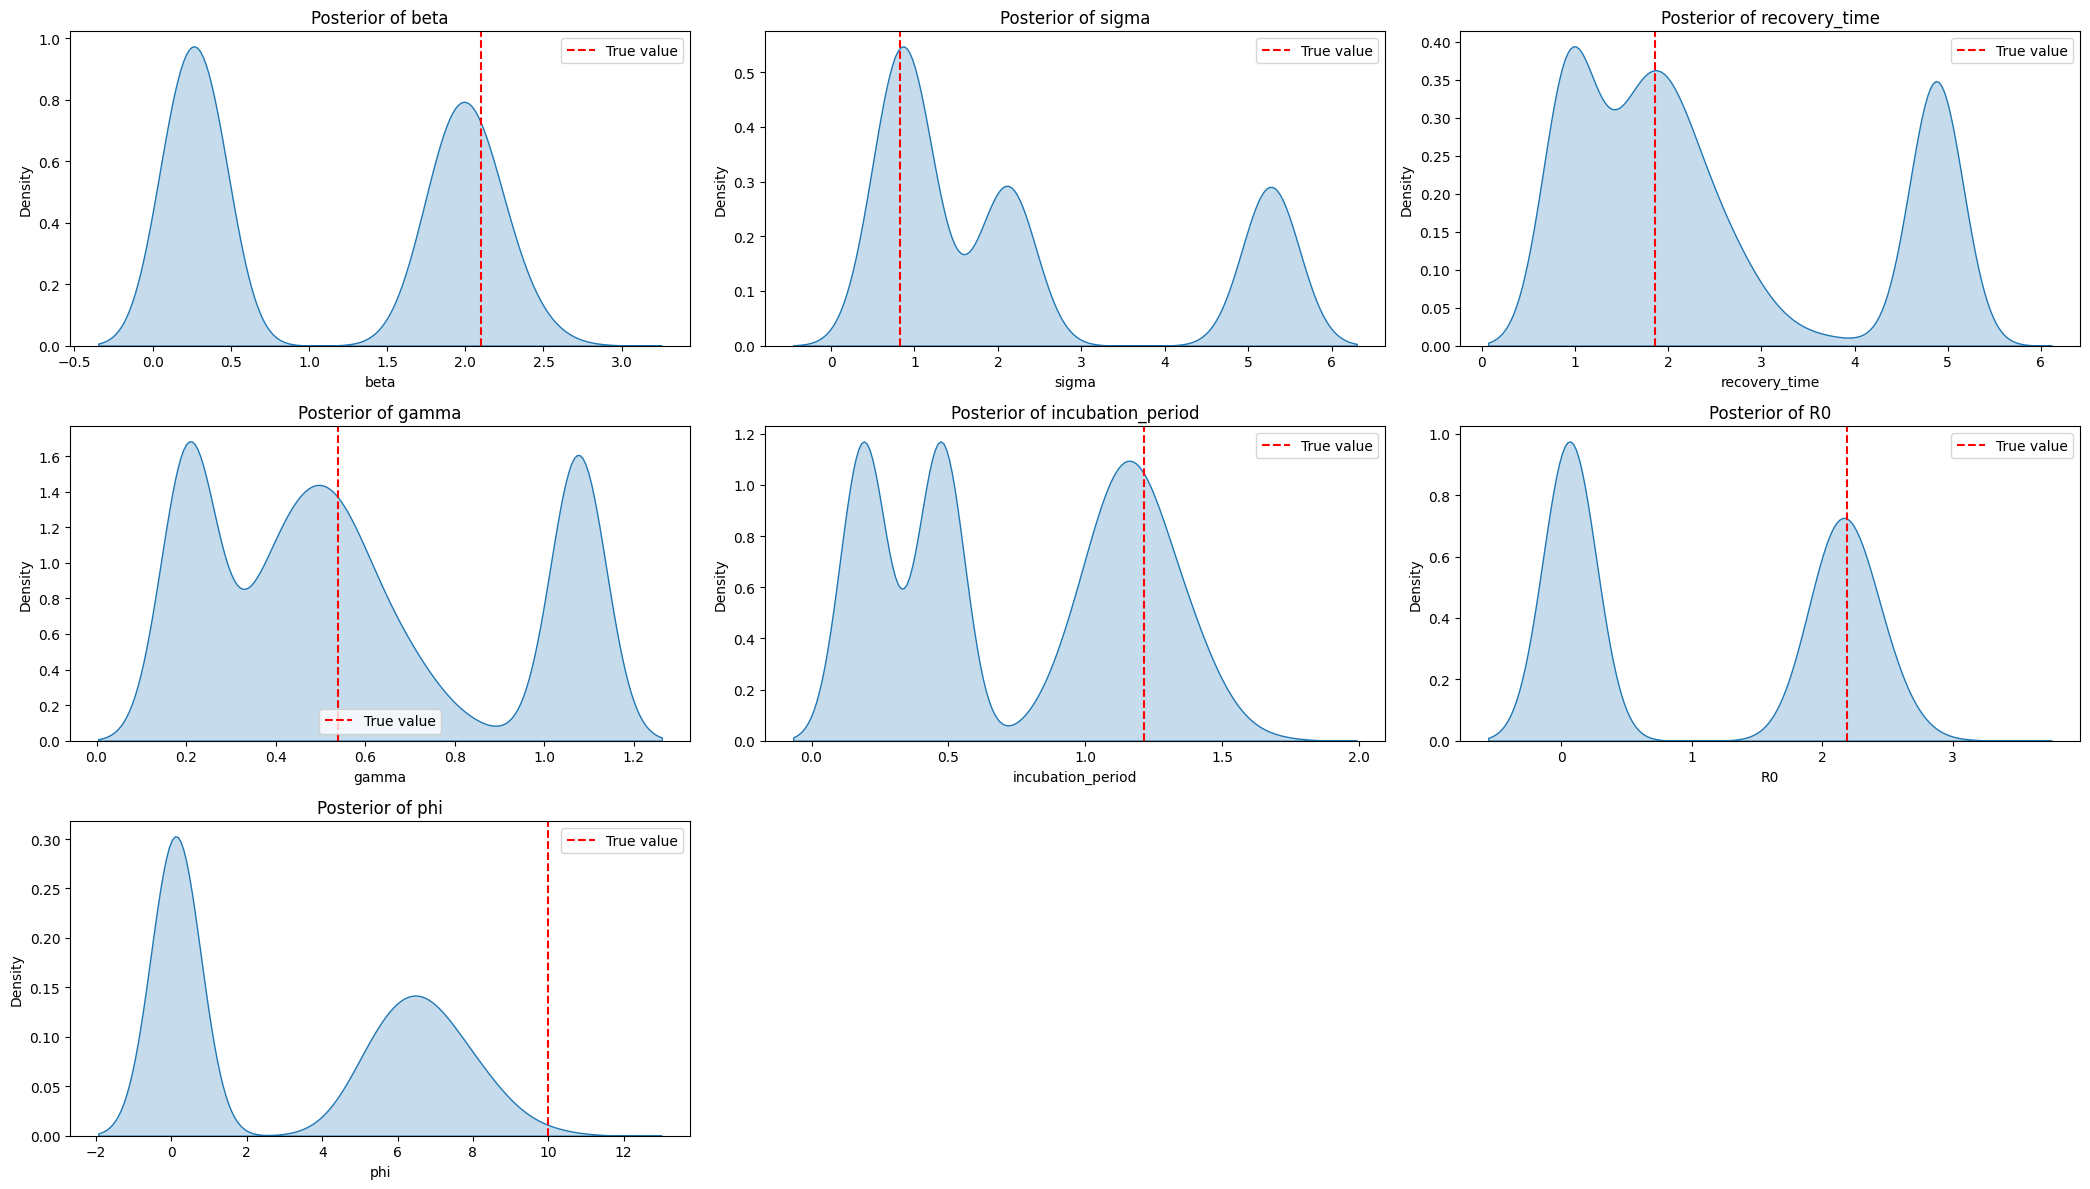

In [40]:
plot_posterior_kde_grid(fit1, parameters1, 3,t1, save = 'Checks_for_Guinea')

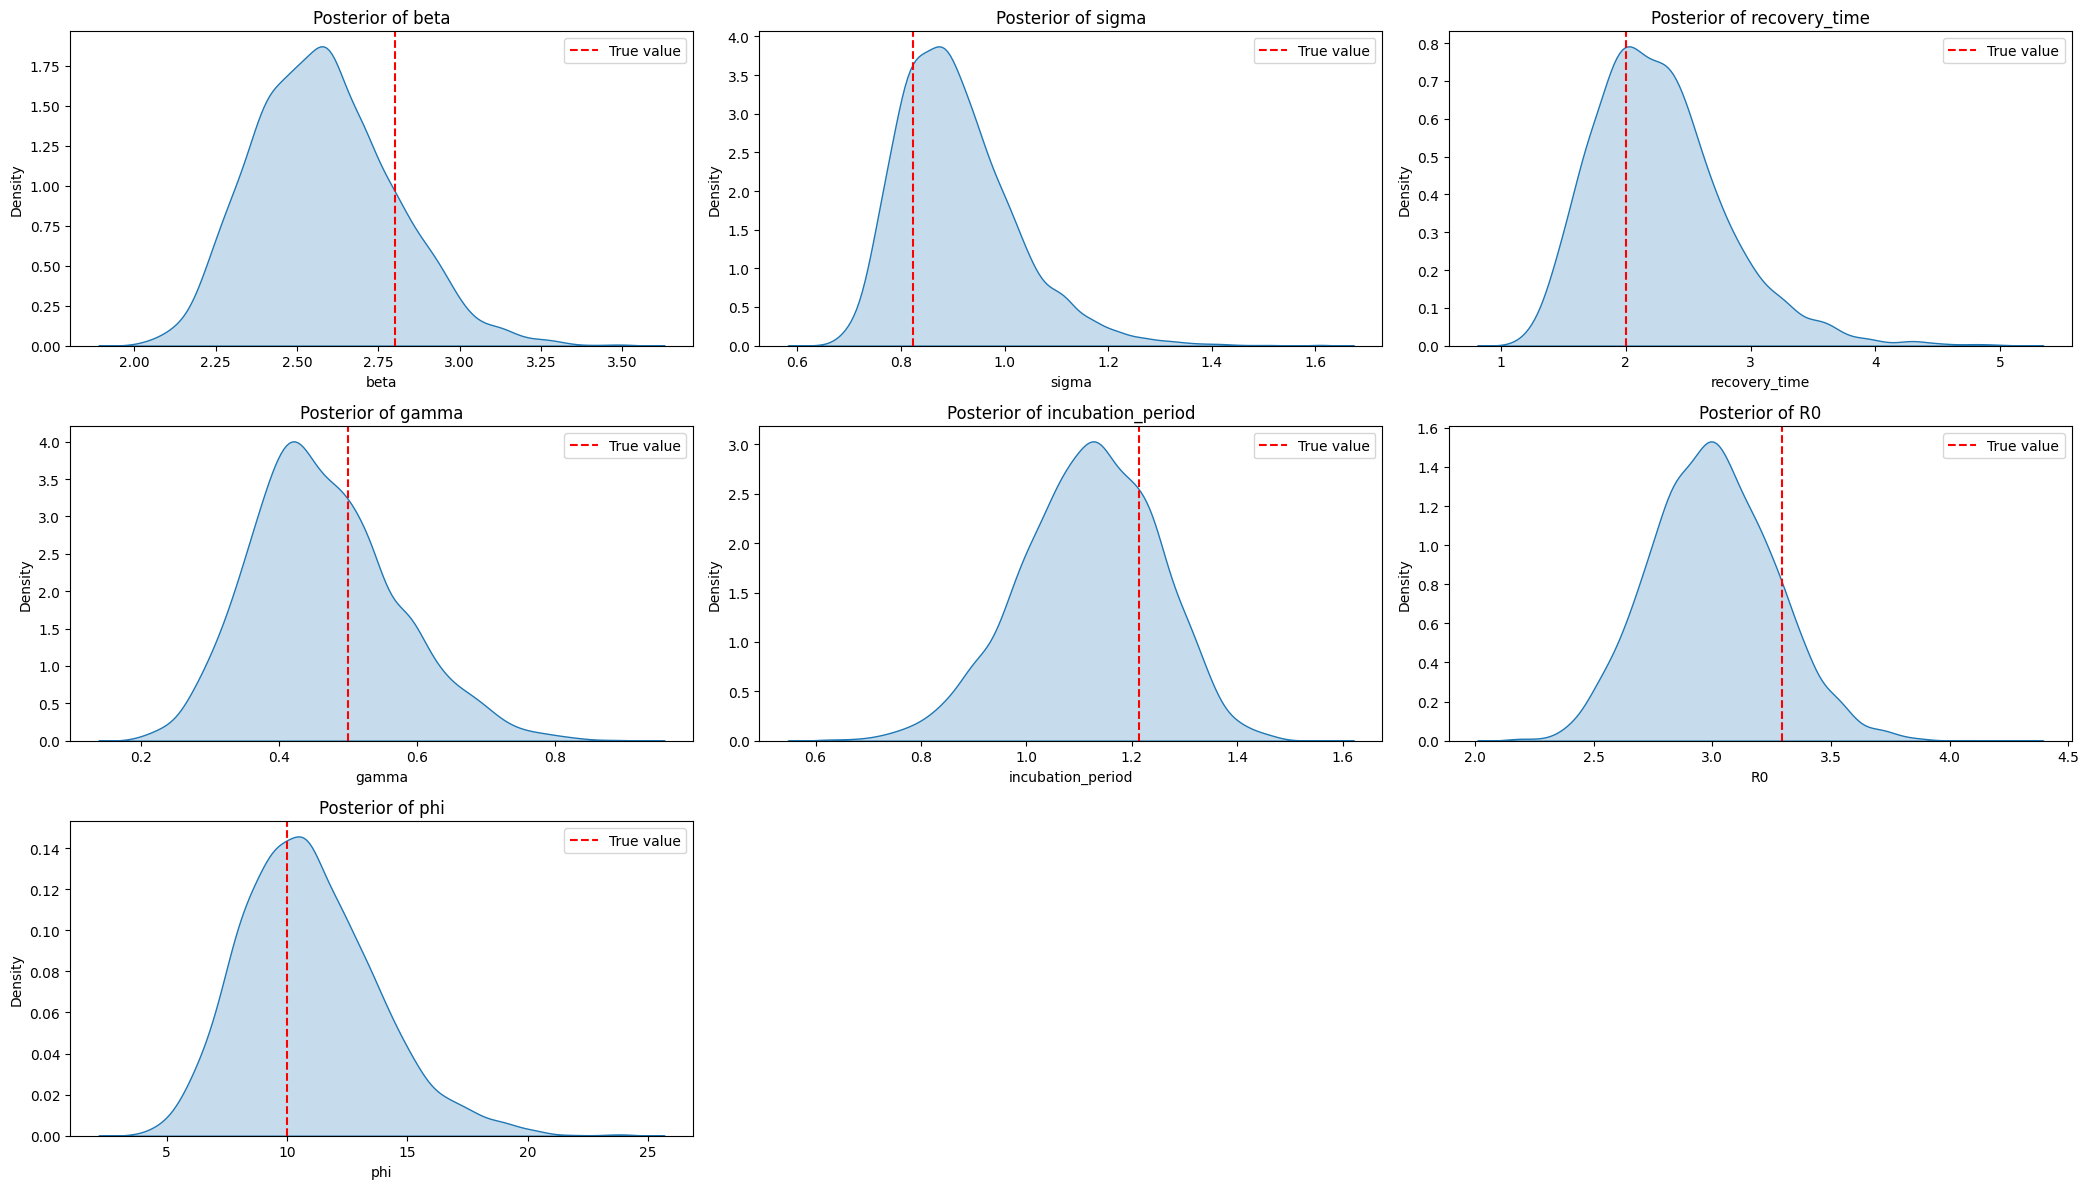

In [41]:
plot_posterior_kde_grid(fit2, parameters1, 3,t2, save = 'Checks_for_Liberia')

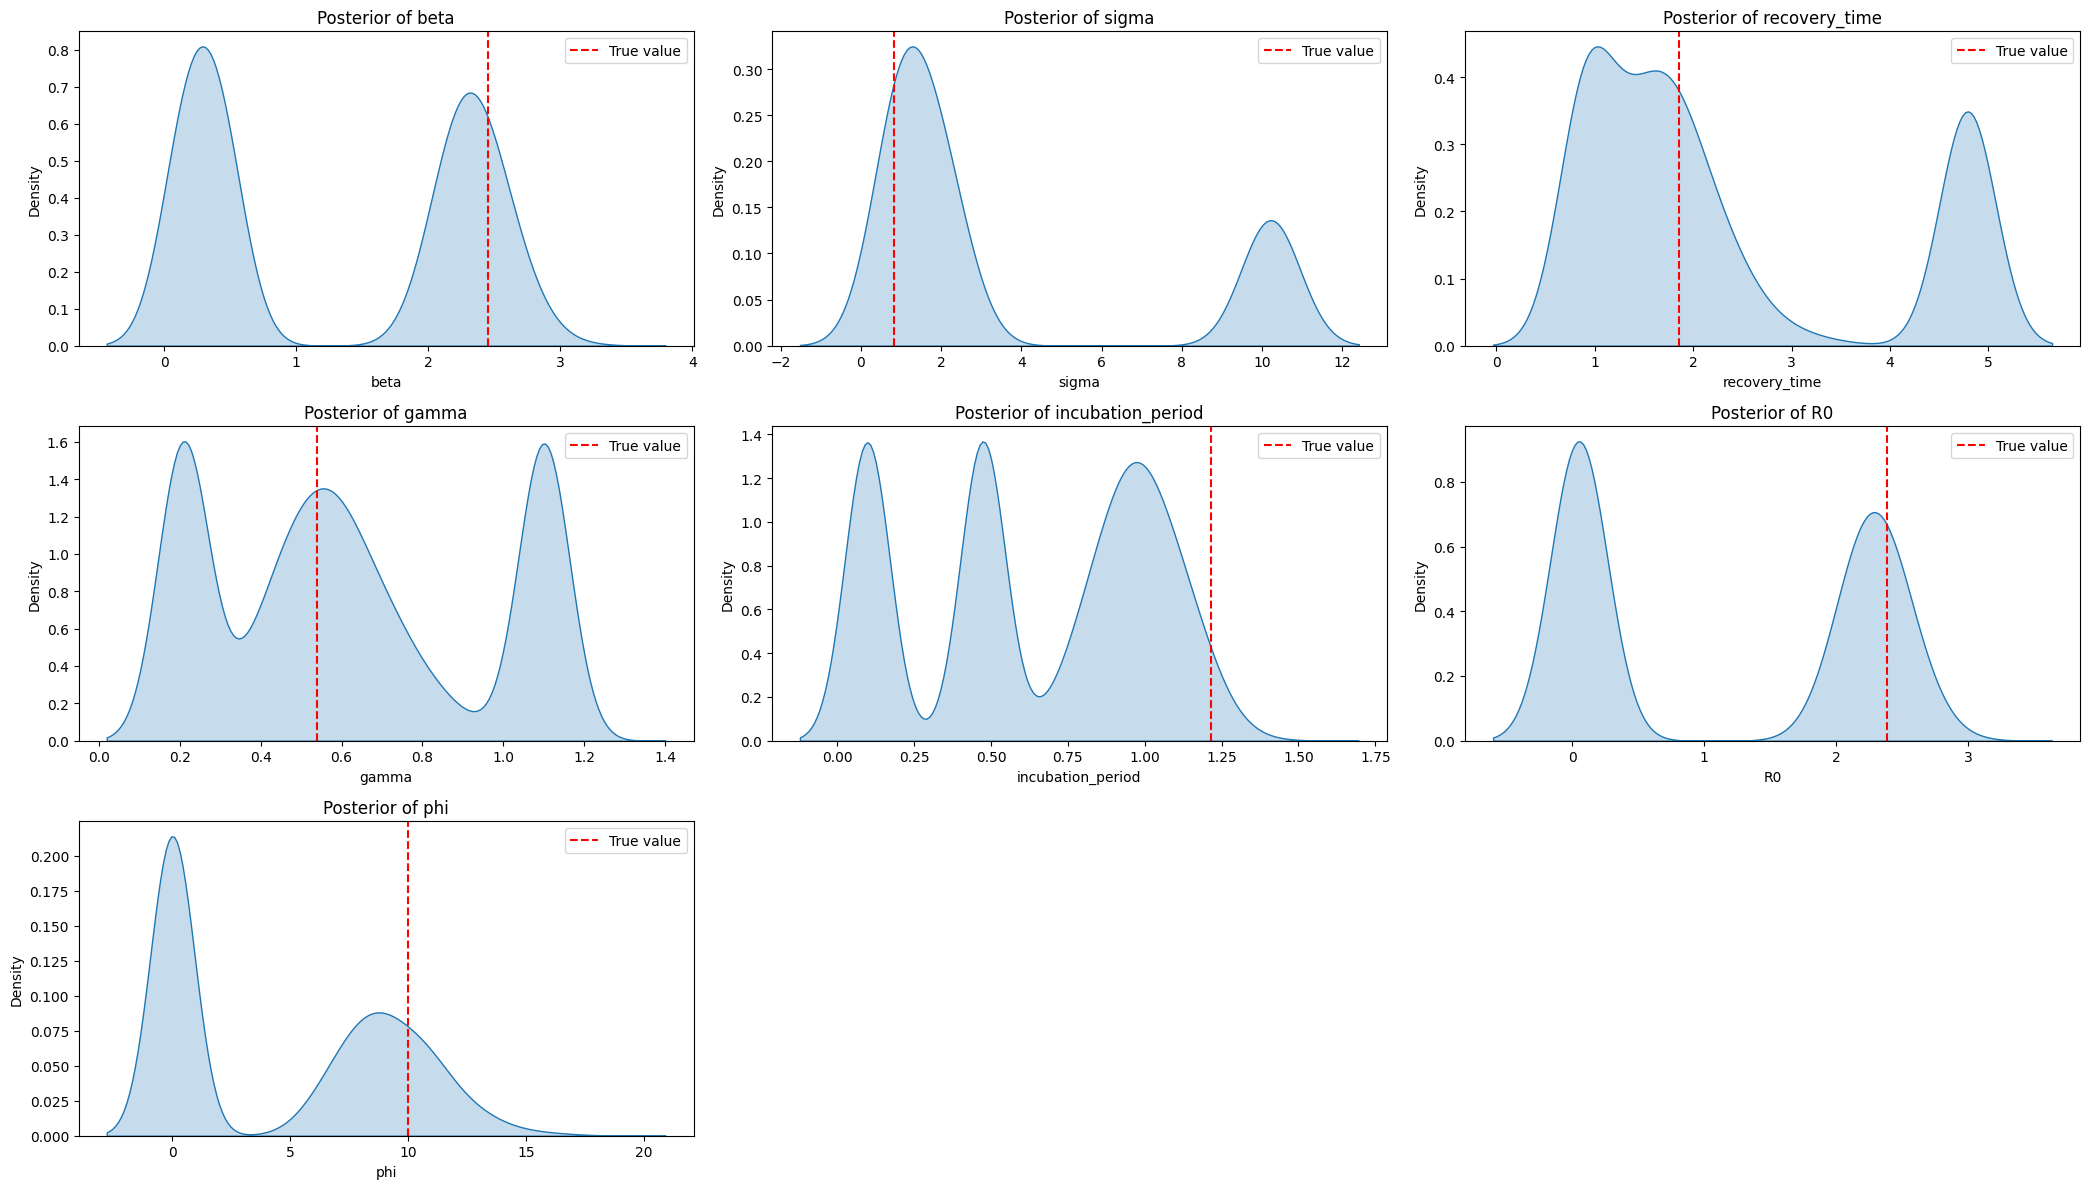

In [42]:
plot_posterior_kde_grid(fit3, parameters1, 3,t3, save = 'Checks_for_Sierra_Leone')

## Plot SEIR Compartments

In [43]:

def plot_compartment(fit, country_idx):
    # Time points and countries
    weeks = np.arange(fit.stan_variable('incidence').shape[1])  # Number of weeks
    countries = ['Guinea', 'Liberia', 'Sierra Leone']

    # Plot incidence (infectious) and reconstructed other compartments
    # for i in range(countries):
    # Create figure
    plt.figure(figsize=(12, 7))
    incidence = np.mean(fit.stan_variable('incidence'), axis=0)

    # Reconstruct approximate compartments (scaled by reporting rate)
    I = incidence
    R = np.cumsum(I) * np.mean(fit.stan_variable('gamma'))
    E = np.roll(I, 1) / np.mean(fit.stan_variable('sigma'))  # Exposed ~ delayed infectious
    # E[0] = 0
    S = N[country_idx] - E - I - R

    # Convert to fractions
    S_frac = S / N[country_idx]
    E_frac = E / N[country_idx]
    I_frac = I / N[country_idx]
    R_frac = R / N[country_idx]

    # Plot
    plt.plot(weeks, S_frac, 'b', label='Susceptible')
    plt.plot(weeks, E_frac, 'y', label='Exposed')
    plt.plot(weeks, I_frac, 'r', label='Infectious')
    plt.plot(weeks, R_frac, 'g', label='Recovered')

    # Formatting
    plt.title(f'{countries[country_idx]} (R0={np.mean(fit.stan_variable("R0")):.2f})')
    plt.ylabel('Fraction of Population')
    plt.grid(True, alpha=0.3)
    # ax.set_ylim(0, 1)

    plt.legend(loc='upper right')
    plt.xlabel('Weeks since outbreak start')
    # plt.tight_layout()
    plt.show()                                                                                      

In [44]:
# plot_compartment(fit_seir_incidence_model, country_idx=0)
# plot_compartment(fit2, country_idx=1)
# plot_compartment(fit3, country_idx=2)

# FITTING FOR 3 PATCHES

In [45]:
weekly = raw[['Guinea_Noise', 'Liberia_Noise', 'SierraLeone_Noise']]
weekly.head()

,Guinea_Noise,Liberia_Noise,SierraLeone_Noise
0,0,0,0
1,8,17,18
2,17,40,52
3,48,56,34
4,45,107,63


In [55]:

N = np.array([11.5e6, 4.5e6, 6.8e6]) 
# N = np.array([2e6, 1.5e6, 1e6])
# N = np.array([110000, 440000, 680000])
# Set the population size

# Define initial conditions
g0 = [N[0]-10, 10, 10, 0, 0, 0]
l0 = [N[1]-10, 10, 10, 0, 0, 0]
s0 = [N[2]-10, 10, 10, 0, 0, 0]

ts = weekly.values.T
y0 = [g0, l0, s0]

beta = np.array([0.3, 0.4, 0.35])*7
sigma = np.array([1/8.5, 1/8.5, 1/8.5])*7
gamma = np.array([1/13, 1/14, 1/13])*7
alpha = np.array([0.06, 0.06, 0.06])*7

phi = 10           # Negative binomial dispersion parameter
reporting_rate = 1  

# Make the data struture
seir_data = {
    'N_countries': 3,
    "n_weeks": len(ts[0]),
    'y0': y0,
    't0': 0,
    "t": np.arange(1, len(ts[0])+1),
    "N": N.astype(int),
    "cases": ts,
    'beta_values': beta,
    'sigma_values': sigma,
    'gamma_values': gamma,
    'alpha_values': alpha,
    'reporting_rate': reporting_rate
}

multi_model = CmdStanModel(stan_file = 'stan files/mult.stan')

In [ ]:
fit_multi_model = multi_model.sample(data = seir_data,
                                     iter_sampling = 1000,
                                     parallel_chains=True,
                                     chains = 4,
                                     seed = 0)

chain 1 |          | 00:00 Status


chain 1 |██████████| 42:43 Iteration: 1900 / 2000 [ 95%]  (Sampling)

































































chain 1 |██████████| 2:33:53 Sampling completed                     
chain 2 |██████████| 2:33:53 Sampling completed                       
chain 3 |██████████| 2:33:53 Sampling completed                       
chain 4 |██████████| 2:33:53 Sampling completed                       

In [ ]:
print(fit_multi_model.diagnose())

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [ ]:
multy_fit_summary = fit_multi_model.summary()
multy_fit_summary.filter(items=("beta[1]","beta[2]", "beta[3]", "sigma", "recovery_time",
                                 "gamma", "incubation_period", "R0[1]","R0[2]", "R0[3]",
                                   "phi", "phi_inv"), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
beta[1],1.885630,0.004056,0.250185,0.246771,1.526210,1.855620,2.332290,4148.72,2508.59,1.00024
beta[2],2.576200,0.003592,0.225291,0.212983,2.242040,2.556660,2.976690,4241.10,3084.23,1.00392
beta[3],2.223900,0.004070,0.247477,0.239195,1.874870,2.197870,2.669390,4078.88,2577.14,1.00219
R0[1],2.689930,0.006674,0.432196,0.415002,2.088880,2.633940,3.469550,4347.45,3106.04,1.00053
R0[2],3.169770,0.006522,0.431935,0.410428,2.552460,3.131120,3.940630,4620.08,2900.41,1.00035
R0[3],2.347150,0.004116,0.283593,0.277884,1.944400,2.314890,2.861190,4879.20,2645.88,1.00203
phi,6.234070,0.013313,0.959251,0.951125,4.760100,6.185530,7.918790,5360.60,3023.43,1.00083
phi_inv,0.164252,0.000356,0.025544,0.024791,0.126282,0.161668,0.210079,5360.40,3023.43,1.00064


In [ ]:
# # Extract posterior samples
# post_no = fit_multi_model.draws_pd()

# ## save the posterior samples
# post_no.to_csv('./Data/posterior_samples_no_coupling.csv', index=False)

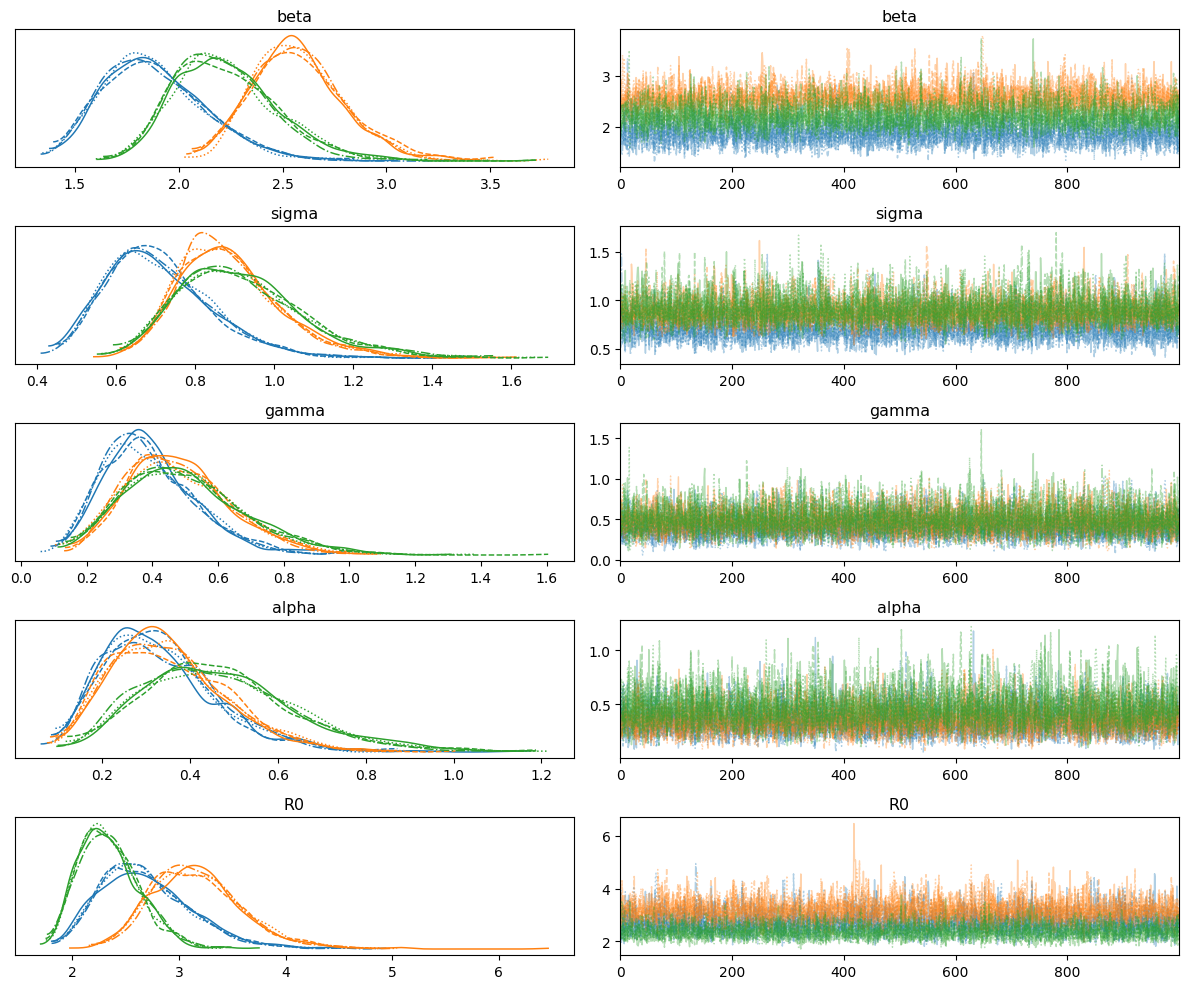

In [ ]:

az.plot_trace(fit_multi_model, var_names=["beta", "sigma", "gamma", "alpha", "R0"])
plt.tight_layout()
plt.show()

# POSTERIOR PREDICTIVE CHECK

In [ ]:
# Get available variables
# Assuming `fit` is your CmdStanMCMC object from fitting the model
posterior_samples = fit_multi_model.draws_pd()  # returns a pandas DataFrame

beta = np.array([0.3, 0.4, 0.3])*7
sigma = np.array([1/8.5, 1/8.5, 1/8.5])*7
gamma = np.array([1/13, 1/14, 1/13])*7   # 1/infectious period (Ebola: ~7 days)
alpha = np.array([0.05, 0.05, 0.05])*7

phi = 10            # Negative binomial dispersion parameter
reporting_rate = 1
r = (beta/(gamma+alpha))
rec = (1.0/gamma)
incu = (1.0 / sigma)

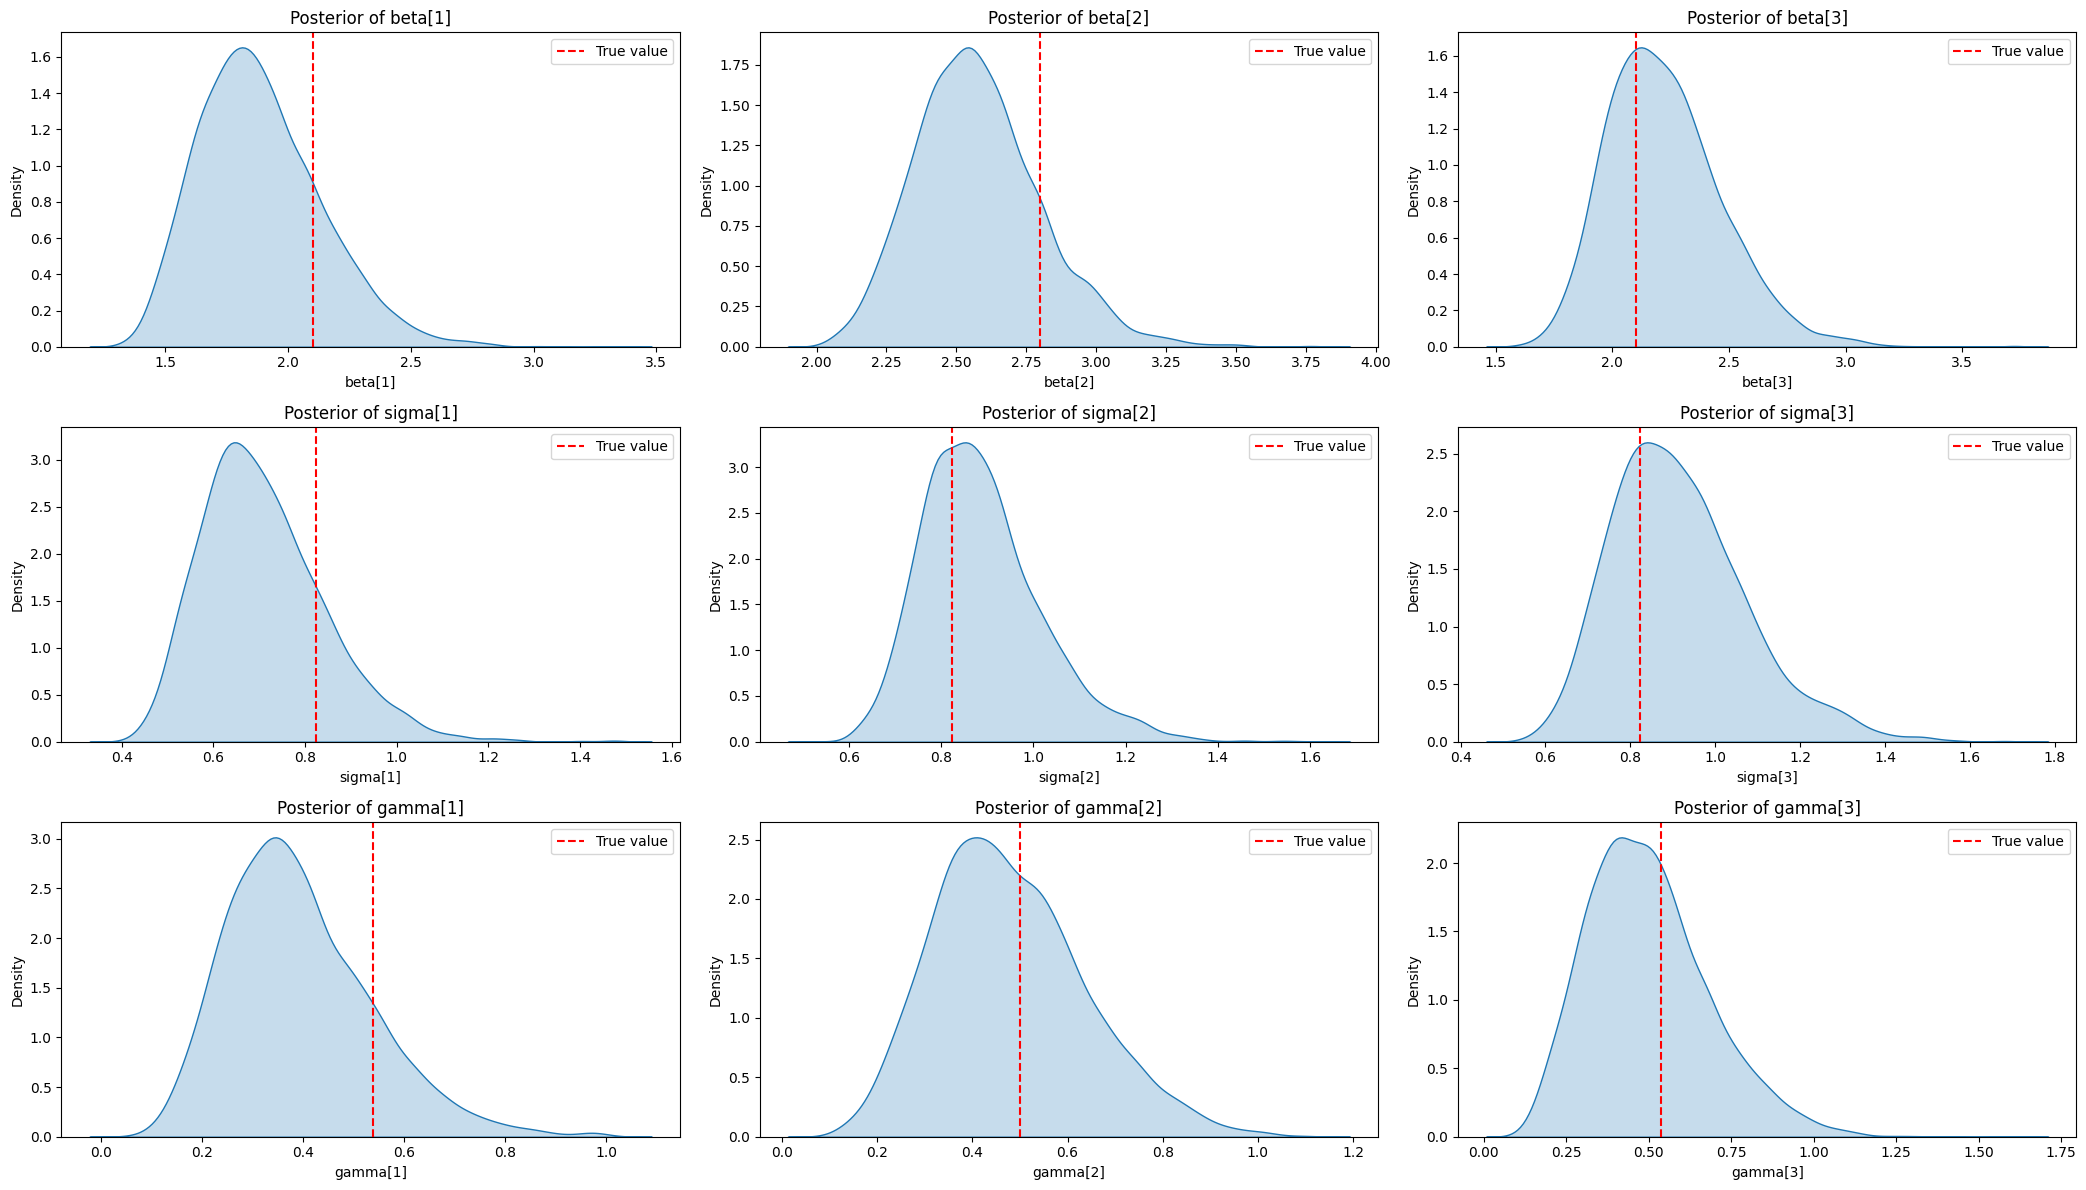

In [ ]:
parameters = ["beta[1]","beta[2]", "beta[3]", 
                "sigma[1]","sigma[2]","sigma[3]", 
                "gamma[1]","gamma[2]","gamma[3]"]
                
t = {'beta[1]': beta[0], 'beta[2]': beta[1], 'beta[3]': beta[2],
    'sigma[1]': sigma[0], 'sigma[2]': sigma[1], 'sigma[3]': sigma[2],   
    'gamma[1]': gamma[0], 'gamma[2]': gamma[1], 'gamma[3]': gamma[2],
    'phi': phi , 'reporting_rate':1}

plot_posterior_kde_grid(fit_multi_model, parameters=parameters, n_cols=3, true_values=t, save = 'Checks_for_betaGammaSigma')

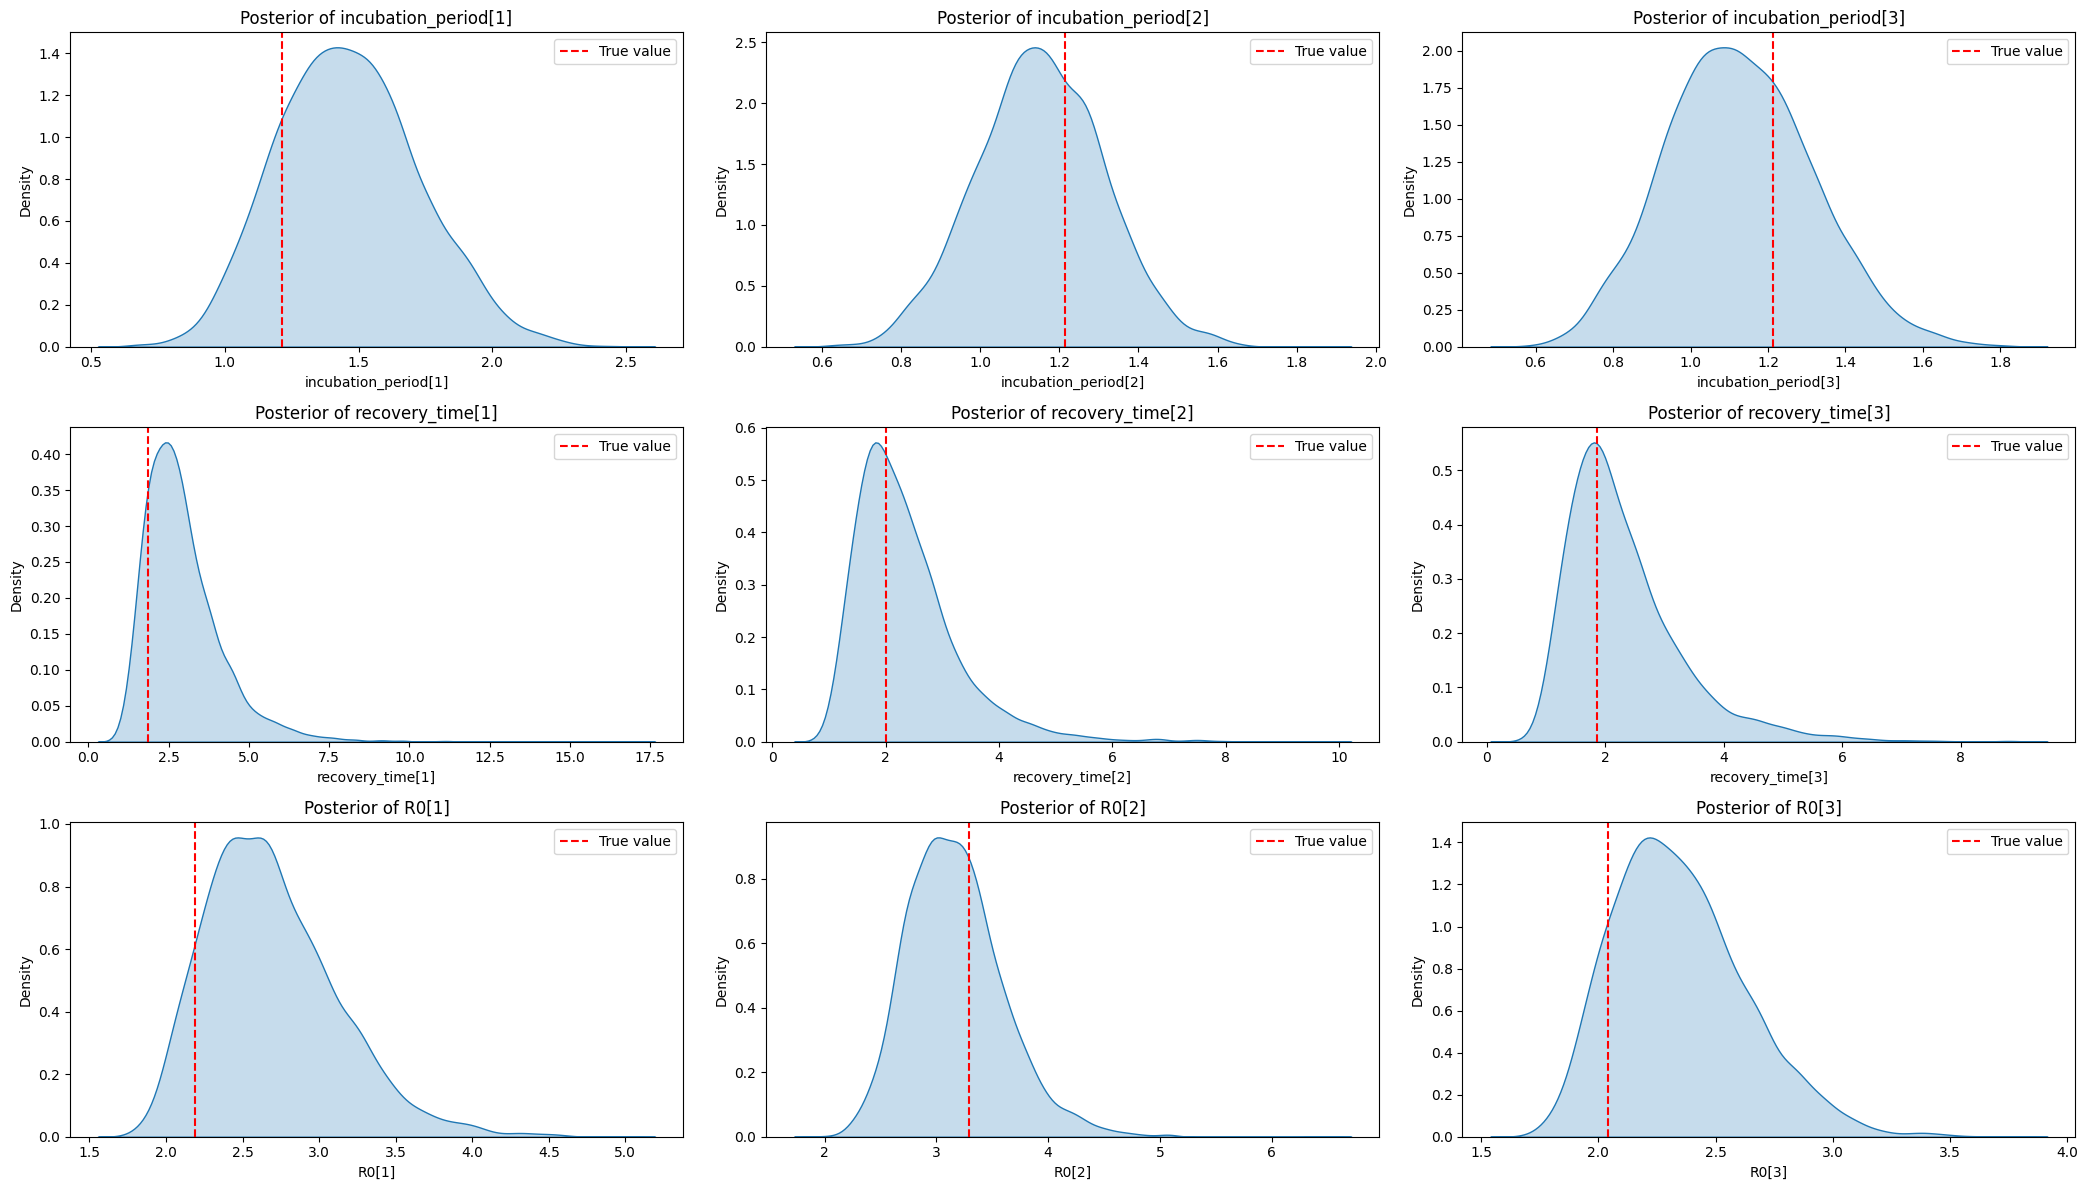

In [ ]:
parameters1 = ["incubation_period[1]","incubation_period[2]","incubation_period[3]", 
                "recovery_time[1]","recovery_time[2]","recovery_time[3]",
                "R0[1]","R0[2]", "R0[3]"]
t1 = {
    'R0[1]': r[0], 'R0[2]': r[1], 'R0[3]': r[2], 
    'recovery_time[1]':rec[0],
    'recovery_time[2]':rec[1],
    'recovery_time[3]':rec[2],
    'incubation_period[1]': incu[0],
    'incubation_period[2]': incu[1],
    'incubation_period[3]': incu[2]}


plot_posterior_kde_grid(fit_multi_model, parameters=parameters1, 
                        n_cols=3, true_values=t1, save = 'Checks_for_recoveryIncubationR0')

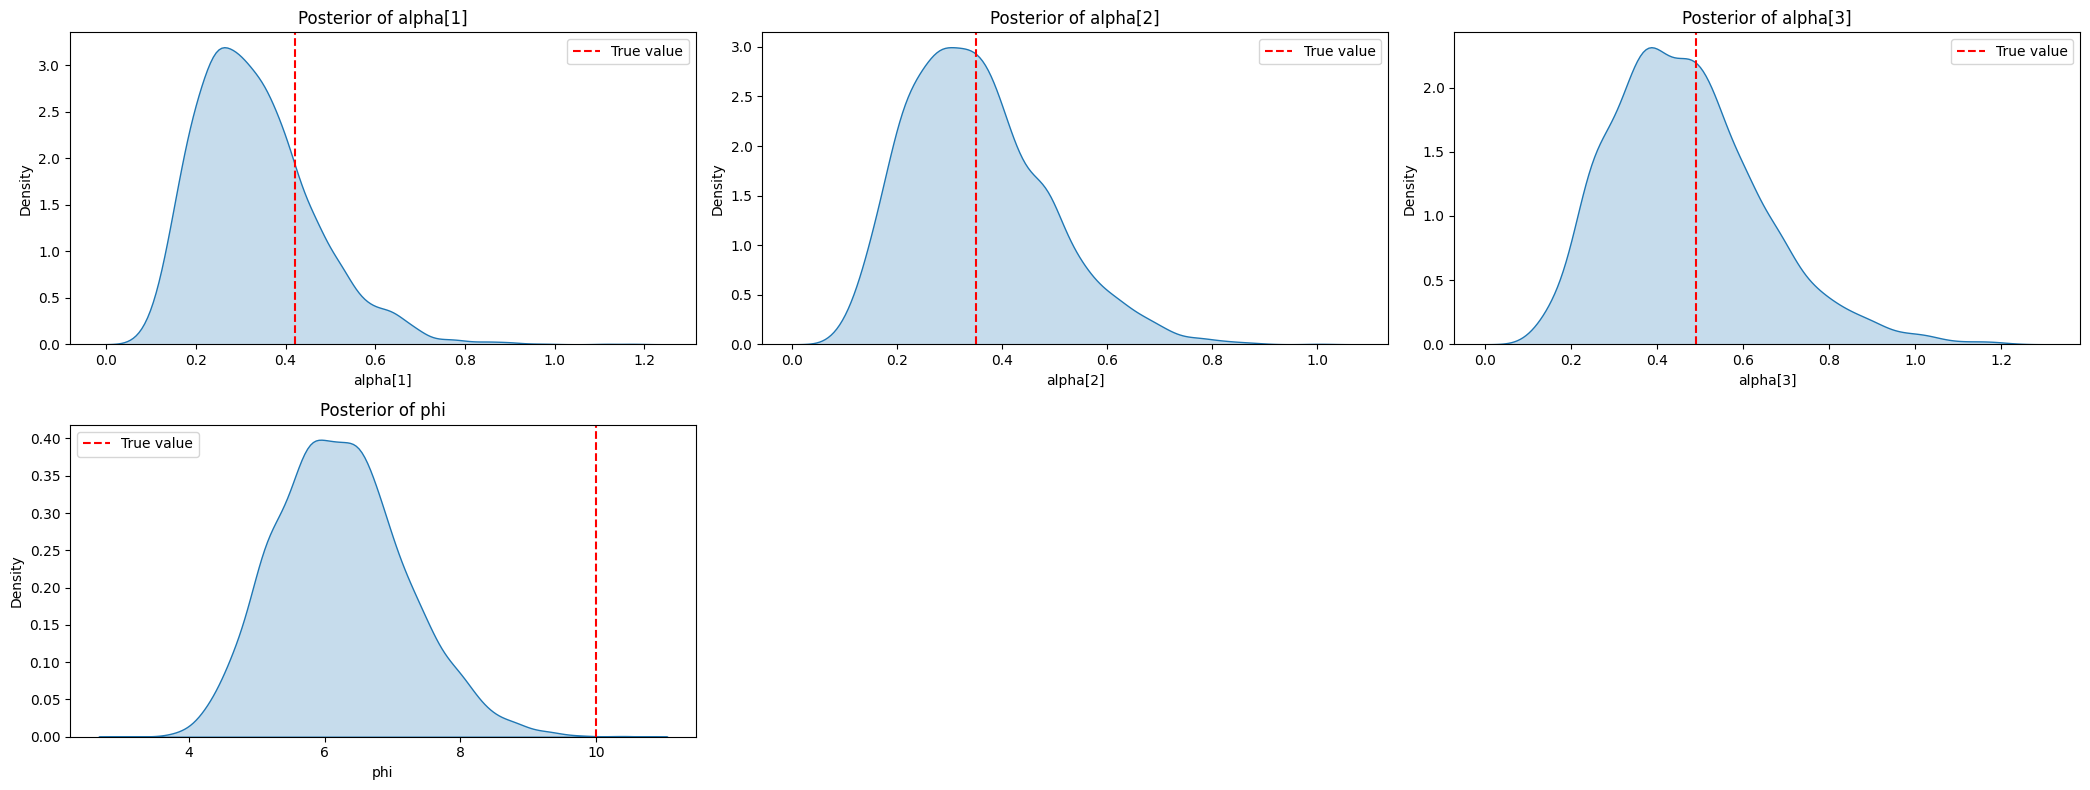

In [ ]:
parameters1 = ['alpha[1]', 'alpha[2]', 'alpha[3]',
               'phi']
t1 = {
    'alpha[1]':alpha[0],
    'alpha[2]':alpha[1],
    'alpha[3]':alpha[2],
    'phi': phi}


plot_posterior_kde_grid(fit_multi_model, parameters=parameters1, 
                        n_cols=3, true_values=t1, save = 'Checks_for_alphaPhi')

# PRIOR PREDICTIVE CHECK

In [ ]:

model_prior = CmdStanModel(stan_file = 'stan files/multi_patch_PRIOR.stan')
prior_check = model_prior.sample(data = seir_data,
                                     iter_sampling = 1000,
                                     chains = 4,
                                     seed = 0)

chain 1 |          | 00:00 Status


chain 1 |▉         | 00:18 Iteration:    1 / 2000 [  0%]  (Warmup)


chain 1 |█▎        | 01:41 Iteration:  100 / 2000 [  5%]  (Warmup)

chain 1 |█▊        | 02:10 Iteration:  200 / 2000 [ 10%]  (Warmup)
chain 1 |██▎       | 02:14 Iteration:  300 / 2000 [ 15%]  (Warmup)




















chain 1 |██▋       | 08:19 Iteration:  400 / 2000 [ 20%]  (Warmup)

chain 1 |███▏      | 08:22 Iteration:  500 / 2000 [ 25%]  (Warmup)

chain 1 |███▋      | 08:27 Iteration:  600 / 2000 [ 30%]  (Warmup)

chain 1 |████      | 08:42 Iteration:  700 / 2000 [ 35%]  (Warmup)

chain 1 |████▌     | 08:44 Iteration:  800 / 2000 [ 40%]  (Warmup)

chain 1 |█████▍    | 08:56 Iteration: 1000 / 2000 [ 50%]  (Warmup)

chain 1 |████████▏ | 09:34 Iteration: 1500 / 2000 [ 75%]  (Sampling)

chain 1 |████████▋ | 09:40 Iteration: 1600 / 2000 [ 80%]  (Sampling)

chain 1 |█████████ | 09:55 Iteration: 1700 / 2000 [ 85%]  (Sampling)

chain 1 |█████████▌| 09:58 Iteration: 1800 / 2000 [ 90%

In [ ]:
import math
def plot_prior(model, param_names, boundary, ncols=3, 
               figsize_per_plot=(8, 7), 
               sharey=True, 
               legend_on_first=True):
    

    countries = ['Guinea','Liberia','Sierra Leone']
    n_params = len(param_names)
    nrows   = math.ceil(n_params / ncols)
    fig_w   = figsize_per_plot[0] * ncols
    fig_h   = figsize_per_plot[1] * nrows+1
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h))
    
    # flatten even if nrows or ncols == 1
    axes = np.array(axes).reshape(-1)
    
    for i, (ax, pname) in enumerate(zip(axes, param_names)):
        # pull samples: shape (n_samples, n_patches)
        samples = model.stan_variable(pname)
        df = pd.DataFrame(samples, columns=countries)
        
        # plot densities
        df.plot(kind='density', ax=ax, legend=False)
        ax.set_title(f'Prior predictive check for {pname}')
        ax.set_xlabel(pname)
        ax.grid(True)
        ax.axvline(x=boundary[i*2], color='r')
        ax.axvline(x=boundary[i*2+1], color='r')
    
    # hide any unused axes
    for ax in axes[n_params:]:
        ax.set_visible(False)

    
    # add legend if desired
    if legend_on_first and n_params > 0:
        axes[0].legend(countries, title='Patch')
    
    plt.tight_layout()
    return fig, axes


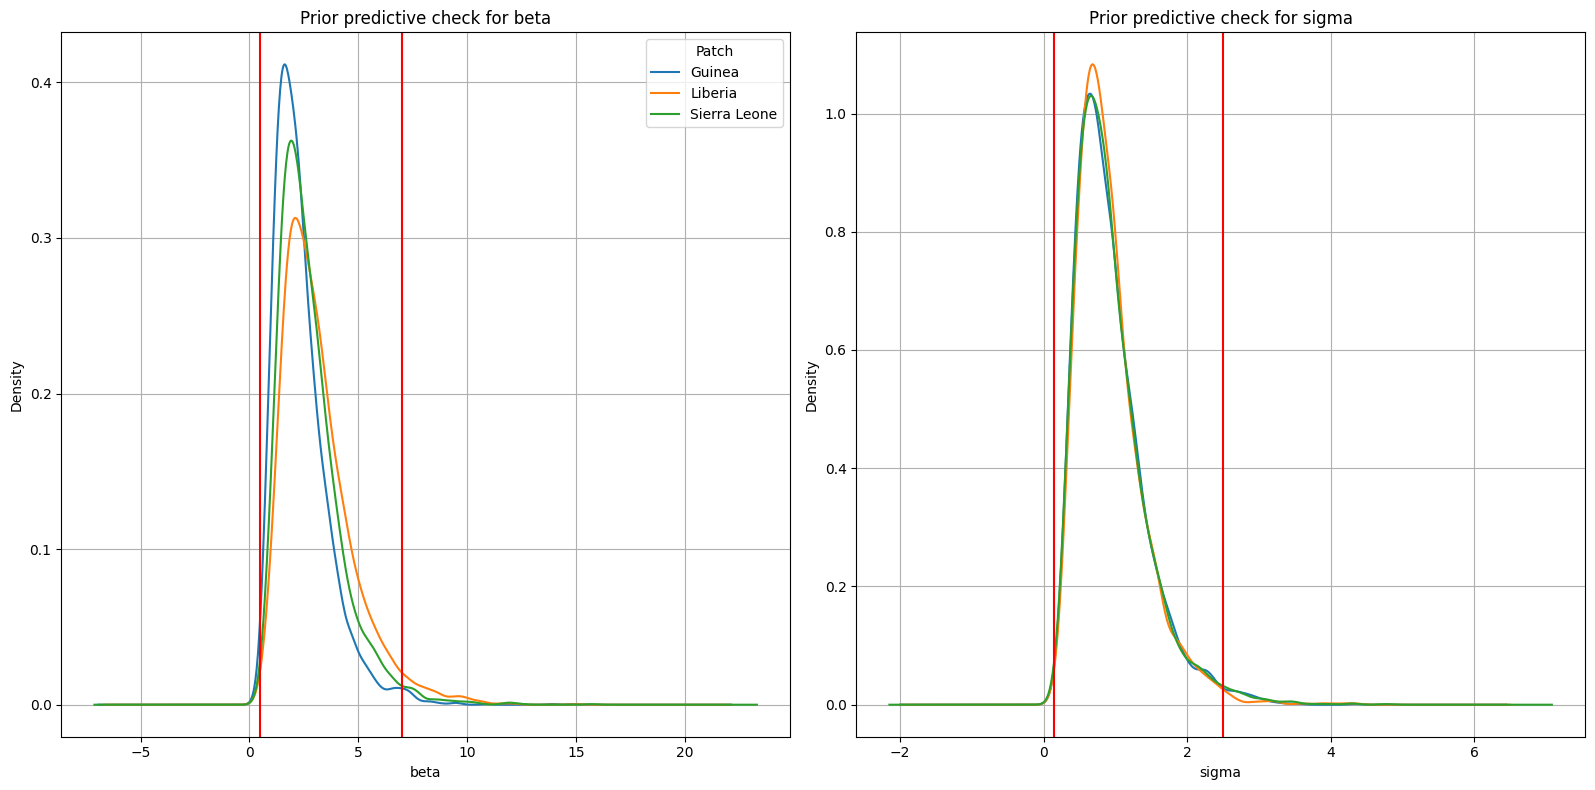

In [ ]:
params = ['beta','sigma']
boundaries = [0.5, 7, 0.14, 2.5]

# 5 parameters → grid of 2×3 (since ncols=3)
fig, axes = plot_prior(prior_check, params, boundary = boundaries, ncols=3)
plt.show()

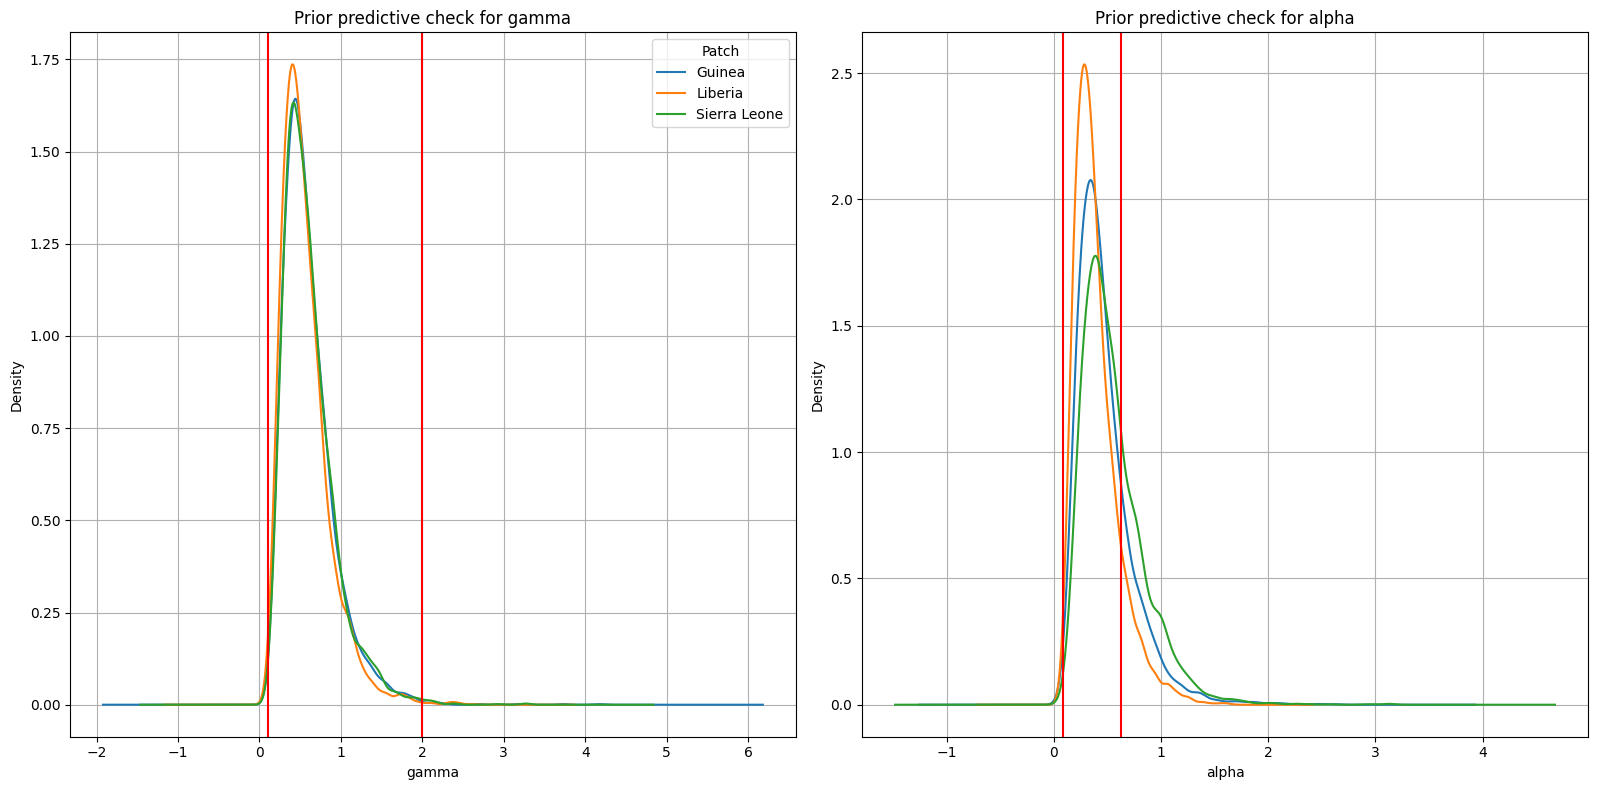

In [ ]:
params = ['gamma', 'alpha']
boundaries = [0.1, 2.0, 0.09, 0.63]

# 5 parameters → grid of 2×3 (since ncols=3)
fig, axes = plot_prior(prior_check, params, boundary = boundaries, ncols=3)
plt.show()

In [ ]:
# infection_draws = prior_check.draws_pd("y")
# lines = plt.plot(range(1,15),
#                  infection_draws,
#                  color = "k", alpha = 0.1)
# plt.axhline(y=N[0], color='r', linestyle='--')
# plt.xlabel('Time')
# plt.ylabel('Number of infections')
# plt.show()

# R0

from sympy import *
init_printing()